In [28]:
import pickle
import numpy as np
from pathlib import Path
from dataclasses import dataclass

# ── Required: define Params before unpickling so pickle can resolve the class ──
@dataclass
class Params:
    logit_pi:  np.ndarray   # (J,)
    alpha:     np.ndarray   # (J, J)
    beta:      np.ndarray   # (J, J, P)
    mu:        np.ndarray   # (J, D)
    W:         np.ndarray   # (J, D, K)
    log_sigma: np.ndarray   # (J, D)

# Load artifacts from the pickle file
artifact_candidates = [
    Path("artifacts/best_model_artifacts_dataset2_3_2_4_8_03.pkl"),
    Path("artifacts/best_model_artifacts_dataset2_2emissions_4covariates_02.pkl"),
    Path("artifacts/best_model_artifacts_dataset2_2emisisons_4covariates_01pkl"),
]
artifacts_path = next((p for p in artifact_candidates if p.exists()), None)
if artifacts_path is None:
    raise FileNotFoundError("Artifact not found. Checked: " + ", ".join(str(p) for p in artifact_candidates))

with open(artifacts_path, 'rb') as f:
    artifacts = pickle.load(f)

print(f"Loaded artifact: {artifacts_path}")
print("Loaded artifacts keys:", list(artifacts.keys()))

# Extract key components
best_model = artifacts['best_model']
best_J = artifacts['best_J']

# emission_cols may be None if not saved by the training notebook;
# recover from final_cfg if available, else fall back to known column list
emission_cols = artifacts.get('emission_cols')
if emission_cols is None:
    cfg = artifacts.get('final_cfg', {})
    emission_cols = getattr(cfg, 'emission_cols', None) or cfg.get('emission_cols', None)
if emission_cols is None:
    # D=2: override_rate removed (= 1 − ai_decision_authority_share by construction)
    emission_cols = ["ai_decision_authority_share", "share_authority_esc"]
    print("⚠️  emission_cols was None in artifact — using fallback:", emission_cols)

# Also load label_map / state_order_1idx if saved in artifact
label_map        = artifacts.get('label_map')
state_order_1idx = artifacts.get('state_order_1idx')

# Create a simple namespace for data
class DataNamespace:
    pass

data = DataNamespace()

print(f"Best model loaded with J={best_J} states, D={best_model.mu.shape[1]} emissions")
print(f"Emission columns: {emission_cols}")
print(f"Model dimensions: J={best_J}, D={best_model.mu.shape[1]}, "
      f"P={best_model.beta.shape[2]}, K={best_model.W.shape[2]}")
if label_map:
    print(f"Label map from artifact: {label_map}")

Loaded artifact: artifacts\best_model_artifacts_dataset2_3_2_4_8_03.pkl
Loaded artifacts keys: ['best_model', 'best_J', 'best_res_final', 'final_cfg', 'll_total', 'k_params', 'n_obs_total', 'aic', 'bic', 'emission_cols', 'transition_cols', 'control_cols', 'label_map', 'state_order_1idx', 'y_scaler', 'x_scaler', 'z_scaler']
⚠️  emission_cols was None in artifact — using fallback: ['ai_decision_authority_share', 'share_authority_esc']
Best model loaded with J=3 states, D=2 emissions
Emission columns: ['ai_decision_authority_share', 'share_authority_esc']
Model dimensions: J=3, D=2, P=4, K=8


In [29]:
# Compatibility patch for transition covariate names used across analysis cells
if isinstance(artifacts, dict) and artifacts.get("transition_cols") is not None:
    _orig_cols = list(artifacts.get("transition_cols"))
    transition_cols_model = [c[:-2] if isinstance(c, str) and c.endswith("_c") else c for c in _orig_cols]
else:
    transition_cols_model = [
        "within_unit_temporal_benchmark",
        "horizontal_peer_benchmark",
        "threshold_benchmark",
        "transparency_level_norm",
        "transparency_x_operational",
        "transparency_x_temporal",
    ]

# Keep only fitted P covariates
transition_cols_model = transition_cols_model[: int(best_model.beta.shape[2])]
artifacts["transition_cols"] = transition_cols_model

transition_nice_map = {
    "within_unit_temporal_benchmark": "Temporal benchmark",
    "horizontal_peer_benchmark": "Peer benchmark",
    "threshold_benchmark": "Threshold shock",
    "transparency_level_norm": "Transparency Level (norm)",
    "transparency_x_operational": "Transparency × Operational Gap",
    "transparency_x_temporal": "Transparency × Temporal Benchmark",
    "transparency_x_threshold": "Transparency × Threshold",
}

print("Transition covariates in use:", transition_cols_model)
print(f"Aligned to fitted P={best_model.beta.shape[2]}")

Transition covariates in use: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'threshold_benchmark', 'transparency_level_norm']
Aligned to fitted P=4


## Model Selection and Parameter Estimation


In [30]:

# ============================================================
# 3. Inspect Estimated Parameters
#   - Uses best_model, best_J, emission_cols from artifact cell
#   - Emissions on original scale via artifacts["y_scaler"]
#   - Transition intercepts alpha + mean transition matrix A
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax

# Use variables loaded from artifacts (cell 1)
# best_model, best_J, emission_cols already set

# ----------------------------
# Emissions (original scale)
# ----------------------------
y_sc = artifacts["y_scaler"]
mu_orig    = y_sc.inverse_transform(best_model.mu)           # (J, D)
sigma_orig = np.exp(best_model.log_sigma) * y_sc.scale_      # (J, D)

print(f"Best model: J={best_J} hidden states, D={len(emission_cols)} emissions\n")

em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": float(mu_orig[j, d]),
            "Std (orig scale)":  float(sigma_orig[j, d]),
        })

em_df = pd.DataFrame(em_rows)
em_df["Mean (orig scale)"] = em_df["Mean (orig scale)"].round(4)
em_df["Std (orig scale)"]  = em_df["Std (orig scale)"].round(4)

print("â”€â”€ Emission Parameters (original scale) â”€â”€")
display(em_df)

# ----------------------------
# Initial state distribution Ï€
# ----------------------------
pi = softmax(best_model.logit_pi)   # (J,)
print("\nâ”€â”€ Initial State Distribution (Ï€) â”€â”€")
for j in range(best_J):
    print(f"  Ï€(state {j+1}) = {pi[j]:.4f}")

# ----------------------------
# Transition intercepts (logit scale) Î±
# ----------------------------
print("\nâ”€â”€ Transition Intercept Matrix (Î± logits) â”€â”€")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(alpha_df)

# ----------------------------
# Mean transition matrix A at mean X
# Uses data.X if already populated by the posterior cell, else skips
# ----------------------------
if hasattr(data, "X") and data.X:
    X_stack = np.stack(data.X)                            # (N, T, P)
    X_mean  = np.nanmean(X_stack[:, 1:, :], axis=(0, 1)) # (P,)
    logits_mean = (best_model.alpha
                   + np.tensordot(best_model.beta, X_mean, axes=([2], [0])))  # (J, J)
    A_mean = softmax(logits_mean, axis=1)

    print("\nâ”€â”€ Mean Transition Matrix (A) at mean X â”€â”€")
    A_df = pd.DataFrame(
        np.round(A_mean, 4),
        index=[f"from {j+1}" for j in range(best_J)],
        columns=[f"to {j+1}" for j in range(best_J)]
    )
    display(A_df)
else:
    print("\nâ”€â”€ Mean Transition Matrix â”€â”€")
    print("  (Run the Posterior cell first to populate data.X, then re-run this cell)")


Best model: J=3 hidden states, D=2 emissions

â”€â”€ Emission Parameters (original scale) â”€â”€


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.5378,0.0151
1,1,share_authority_esc,0.3623,0.0161
2,2,ai_decision_authority_share,0.5478,0.0086
3,2,share_authority_esc,0.3522,0.0100
4,3,ai_decision_authority_share,0.3406,0.0491
5,3,share_authority_esc,0.2171,0.0449



â”€â”€ Initial State Distribution (Ï€) â”€â”€
  Ï€(state 1) = 0.5358
  Ï€(state 2) = 0.0976
  Ï€(state 3) = 0.3667

â”€â”€ Transition Intercept Matrix (Î± logits) â”€â”€


,to 1,to 2,to 3
from 1,3.138,1.519,-2.320
from 2,3.430,2.810,-4.076
from 3,6.261,4.509,-7.994



â”€â”€ Mean Transition Matrix â”€â”€
  (Run the Posterior cell first to populate data.X, then re-run this cell)


## State Labelling

In [31]:
# ============================================================
# STATE LABELING (model-aware; supports J=2/3/4+)
# Requires: mu_orig, emission_cols, best_J (from prior cells)
# ============================================================

import numpy as np

# Primary labeling axis: ai_decision_authority_share
authority_idx = emission_cols.index("ai_decision_authority_share")

mu_authority = mu_orig[:, authority_idx]          # (J,)
ranked0 = np.argsort(mu_authority)                # 0-based ascending by authority
state_order_1idx = (ranked0 + 1).tolist()         # 1-based display order

# Label templates by rank position (lowest -> highest authority)
if best_J == 2:
    rank_labels = ["Aversion", "Appreciation"]
elif best_J == 3:
    rank_labels = ["Aversion", "Neutral", "Appreciation"]
elif best_J == 4:
    rank_labels = ["Strong Aversion", "Mild Aversion", "Mild Appreciation", "Strong Appreciation"]
else:
    rank_labels = [f"State {k+1}" for k in range(best_J)]

label_map = {}
for rank_pos, state_1idx in enumerate(state_order_1idx):
    label_map[state_1idx] = rank_labels[rank_pos]

print(f"\n=== STATE LABELING (J={best_J}) ===")
print("Rule: ascending ai_decision_authority_share")
for state_1idx in state_order_1idx:
    mu_val = mu_authority[state_1idx - 1]
    print(f"→ State {state_1idx} = {label_map[state_1idx]} (μ={mu_val:.4f})")
print("State order for plots:", state_order_1idx)



=== STATE LABELING (J=3) ===
Rule: ascending ai_decision_authority_share
→ State 3 = Aversion (μ=0.3406)
→ State 1 = Neutral (μ=0.5378)
→ State 2 = Appreciation (μ=0.5478)
State order for plots: [3, 1, 2]


## Posterior State Analysis

In [32]:
# ============================================================
# 4. Posterior State Assignment (WITH STATE LABELS)
#   - Robust Excel path resolution
#   - Aligns transition covariates with fitted model P
#   - Computes gamma + long posterior table
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import logsumexp

# ------------------------------------------------------------------
# 4a. Helper functions needed for HMM forward-backward
# ------------------------------------------------------------------

def _softmax(z, axis=-1):
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)


def _log_softmax(z, axis=-1):
    return z - logsumexp(z, axis=axis, keepdims=True)


def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (
        log_norm[None, :] + np.sum(residuals ** 2 / sigma2[None, :, :], axis=2)
    )
    logits_all = p.alpha[None, :, :] + np.einsum('ijp,tp->tij', p.beta, X)
    logQ_all = _log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all


def forward_backward(p, Y, X, Z):
    """Full forward-backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = _softmax(p.logit_pi)

    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1,
        )

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma


# ------------------------------------------------------------------
# 4b. Load data from Excel and build sequences
# ------------------------------------------------------------------

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )

    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )
    temp_mean = df["within_unit_temporal_benchmark"].mean()
    df["within_unit_temporal_benchmark"] = df["within_unit_temporal_benchmark"] - temp_mean

    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0
    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)

    df["transparency_level_norm"] = df["transparency_level"].astype(float) / 3.0

    op_mean = df["kpi_operational_gap_index"].mean()
    df["kpi_operational_gap_index_c"] = df["kpi_operational_gap_index"] - op_mean
    df["transparency_x_operational"] = (
        df["transparency_level_norm"] * df["kpi_operational_gap_index_c"]
    )
    df["transparency_x_temporal"] = (
        df["transparency_level_norm"] * df["within_unit_temporal_benchmark"]
    )

    return df


# Robust data path selection
candidate_paths = [
    Path(r"..\new run\Triadic_Delegation_Dataset_SYNTH_ANALYSIS_v2.xlsx"),
    Path(r"new run\Triadic_Delegation_Dataset_SYNTH_ANALYSIS_v2.xlsx"),
    Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS_v2.xlsx"),
    Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx"),
    Path(r"triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx"),
]

xlsx_path = next((p for p in candidate_paths if p.exists()), None)
if xlsx_path is None:
    raise FileNotFoundError(
        "Could not find analysis Excel file in expected locations: "
        + ", ".join(str(p) for p in candidate_paths)
    )

print(f"Loading data from: {xlsx_path.resolve()}")

df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")
df = build_benchmarks(df)

# Compute share_authority_esc from decision_episode
dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
esc_agg = (
    dec_ep.groupby(["manager_id", "period_id"])
    .agg(n_tasks=("episode_id", "count"), n_escalated=("is_escalated", "sum"))
    .reset_index()
)
esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
df = df.merge(
    esc_agg[["manager_id", "period_id", "share_authority_esc"]],
    on=["manager_id", "period_id"],
    how="left",
)
df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)

# Column definitions
emission_cols_data = ["ai_decision_authority_share", "share_authority_esc"]

transition_cols_all = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]

model_P = int(best_model.beta.shape[2])
transition_cols_data = artifacts.get("transition_cols") if isinstance(artifacts, dict) else None
if transition_cols_data is None:
    transition_cols_data = transition_cols_all[:model_P]
else:
    transition_cols_data = list(transition_cols_data)[:model_P]

control_cols_data = [
    "task_complexity_index",
    "demand_volatility",
    "supply_disruption_count",
    "forecast_accuracy_mape",
    "decision_latency_avg",
    "target_difficulty",
    "performance_pressure_index",
    "recent_negative_shock",
]

required_cols = emission_cols_data + transition_cols_data + control_cols_data
df = df.dropna(subset=required_cols)

Y_list, X_list, Z_list = [], [], []
ids_list, periods_list = [], []

for mid, g in df.groupby("manager_id"):
    g = g.sort_values("period_id")
    Y = g[emission_cols_data].to_numpy(float)
    X = g[transition_cols_data].to_numpy(float)
    Z = g[control_cols_data].to_numpy(float)
    if len(Y) < 3:
        continue
    Y_list.append(Y)
    X_list.append(X)
    Z_list.append(Z)
    ids_list.append(mid)
    periods_list.append(g["period_id"].to_numpy())

# Use scalers from artifacts
y_sc = artifacts["y_scaler"]
x_sc = artifacts["x_scaler"]
z_sc = artifacts["z_scaler"]

if int(x_sc.n_features_in_) != int(X_list[0].shape[1]):
    raise RuntimeError(
        f"Transition feature mismatch: x_scaler expects {x_sc.n_features_in_}, "
        f"but extracted X has {X_list[0].shape[1]} columns: {transition_cols_data}"
    )

Y_list = [y_sc.transform(y) for y in Y_list]
X_list = [x_sc.transform(x) for x in X_list]
Z_list = [z_sc.transform(z) for z in Z_list]

# Populate data namespace
data.Y = Y_list
data.X = X_list
data.Z = Z_list
data.ids = ids_list
data.periods = periods_list

print(f"Managers loaded: {len(data.Y)}")
seq_lens = [len(y) for y in data.Y]
print(f"Total observations: {sum(seq_lens)}")


# ------------------------------------------------------------------
# 4c. Compute gamma and posterior table
# ------------------------------------------------------------------
J = int(best_J)
gamma_list = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    gamma_list.append(np.exp(log_g))

gamma = np.vstack(gamma_list)
n_obs_total = int(gamma.shape[0])

if "label_map" not in globals() or label_map is None:
    label_map = {s: f"State {s}" for s in range(1, J + 1)}
if "state_order_1idx" not in globals() or state_order_1idx is None:
    state_order_1idx = list(range(1, J + 1))

rows = []
for mid, periods, g_i in zip(data.ids, data.periods, gamma_list):
    ml_state = np.argmax(g_i, axis=1) + 1
    for t in range(len(periods)):
        rec = {
            "manager_id": str(mid),
            "period_id": int(periods[t]),
            "most_likely_state": int(ml_state[t]),
            "state_label": label_map.get(int(ml_state[t]), f"State {int(ml_state[t])}"),
        }
        for s in range(J):
            rec[f"gamma_state_{s+1}"] = float(g_i[t, s])
        rows.append(rec)

posteriors = pd.DataFrame(rows)

# Ordered summaries
ordered_states = list(state_order_1idx)
ordered_labels = [label_map.get(s, f"State {s}") for s in ordered_states]

freq_by_state = (
    posteriors["most_likely_state"]
    .value_counts()
    .reindex(ordered_states)
    .fillna(0)
    .astype(int)
)

occ_by_state = pd.Series(
    {s: float(gamma[:, s - 1].mean()) for s in ordered_states},
    name="mean_posterior_occupancy",
)

freq_by_label = (
    posteriors["state_label"]
    .value_counts()
    .reindex(ordered_labels)
    .fillna(0)
    .astype(int)
)

print("\nPosterior assignment counts by state id:")
print(freq_by_state.to_string())

print("\nMean posterior occupancy by state id:")
print(occ_by_state.round(4).to_string())

print("\nPosterior assignment counts by label:")
print(freq_by_label.to_string())

print("\n✓ Posterior state analysis updated and ready for downstream cells.")

Loading data from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\new run\Triadic_Delegation_Dataset_SYNTH_ANALYSIS_v2.xlsx
Managers loaded: 120
Total observations: 3000

Posterior assignment counts by state id:
most_likely_state
3     272
1    2086
2     642

Mean posterior occupancy by state id:
3    0.0908
1    0.7035
2    0.2058

Posterior assignment counts by label:
state_label
Aversion         272
Neutral         2086
Appreciation     642

✓ Posterior state analysis updated and ready for downstream cells.


## Model Summary Table

In [33]:
# ============================================================
#   Robust Wild (Multiplier) Cluster Bootstrap for NH-HMM
#   Focus: Transition coefficients beta (and alpha optionally)
#
#   Improvements over previous version:
#   1) CENTRAL finite differences (more accurate than approx_fprime forward diff)
#   2) Relative / parameter-adaptive finite-difference step sizes
#   3) OPG condition diagnostics + stabilized inverse (pinv fallback)
#   4) Studentized (t-based) bootstrap p-values
#   5) Percentile confidence intervals (CIs)
#
#   Outputs:
#     p_beta_t       : t-based bootstrap p-values for beta
#     se_beta_boot   : bootstrap SEs for beta
#     ci_beta_lo/hi  : percentile CIs for beta
#     diag_boot      : diagnostics dict
# ============================================================

import numpy as np
import pandas as pd
import time
from IPython.display import display

# ------------------------------------------------------------
# 0) Helpers: parameter packing / unpacking
# ------------------------------------------------------------
def _pack(p):
    """Flatten Params fields into a 1-D numpy vector."""
    return np.concatenate([
        p.logit_pi.ravel(),
        p.alpha.ravel(),
        p.beta.ravel(),
        p.mu.ravel(),
        p.W.ravel(),
        p.log_sigma.ravel(),
    ])

def _unpack_vec(v, J, D, P, K):
    """Reconstruct Params dataclass from a flat parameter vector."""
    idx = 0
    logit_pi_  = v[idx: idx + J];                         idx += J
    alpha_     = v[idx: idx + J*J].reshape(J, J);         idx += J*J
    beta_      = v[idx: idx + J*J*P].reshape(J, J, P);    idx += J*J*P
    mu_        = v[idx: idx + J*D].reshape(J, D);         idx += J*D
    W_         = v[idx: idx + J*D*K].reshape(J, D, K);    idx += J*D*K
    log_sigma_ = v[idx: idx + J*D].reshape(J, D);         idx += J*D
    return Params(
        logit_pi=logit_pi_,
        alpha=alpha_,
        beta=beta_,
        mu=mu_,
        W=W_,
        log_sigma=log_sigma_
    )

# ------------------------------------------------------------
# 1) Dimensions and slices
# ------------------------------------------------------------
J_b = int(best_J)
D_b = best_model.mu.shape[1]
P_b = best_model.beta.shape[2]
K_b = best_model.W.shape[2]

v0 = _pack(best_model)
n_params = len(v0)
N_seqs = len(data.Y)

# Build slices for parameter blocks (to extract beta later)
cursor = 0
logit_pi_sl  = slice(cursor, cursor + J_b);                  cursor += J_b
alpha_sl     = slice(cursor, cursor + J_b*J_b);              cursor += J_b*J_b
beta_sl      = slice(cursor, cursor + J_b*J_b*P_b);          cursor += J_b*J_b*P_b
mu_sl        = slice(cursor, cursor + J_b*D_b);              cursor += J_b*D_b
W_sl         = slice(cursor, cursor + J_b*D_b*K_b);          cursor += J_b*D_b*K_b
log_sigma_sl = slice(cursor, cursor + J_b*D_b);              cursor += J_b*D_b

print(f"Parameter vector length: n={n_params}")
print(f"Dimensions: J={J_b}, D={D_b}, P={P_b}, K={K_b}")
print(f"Clusters (manager sequences): N={N_seqs}")

# ------------------------------------------------------------
# 2) Central finite-difference score for one sequence
# ------------------------------------------------------------
def _fd_steps(v, rel_eps=1e-5, abs_floor=1e-6):
    """
    Parameter-adaptive step sizes.
    eps_k = max(abs_floor, rel_eps * max(1, |v_k|))
    """
    return np.maximum(abs_floor, rel_eps * np.maximum(1.0, np.abs(v)))

def _score_seq_central(v, Yi, Xi, Zi, J, D, P, K, eps_vec):
    """
    Central finite-difference score vector for ONE sequence:
        s_i[k] ≈ [ll_i(v + e_k*eps_k) - ll_i(v - e_k*eps_k)] / (2*eps_k)

    Returns
    -------
    s_i : (n_params,)
    """
    s_i = np.zeros_like(v)
    v_plus = v.copy()
    v_minus = v.copy()

    for k in range(len(v)):
        h = eps_vec[k]

        v_plus[k] = v[k] + h
        v_minus[k] = v[k] - h

        p_plus = _unpack_vec(v_plus, J, D, P, K)
        p_minus = _unpack_vec(v_minus, J, D, P, K)

        ll_plus, _ = forward_backward(p_plus, Yi, Xi, Zi)
        ll_minus, _ = forward_backward(p_minus, Yi, Xi, Zi)

        s_i[k] = (ll_plus - ll_minus) / (2.0 * h)

        # reset for next coordinate
        v_plus[k] = v[k]
        v_minus[k] = v[k]

    return s_i

# ------------------------------------------------------------
# 3) Compute per-sequence scores (cluster scores)
# ------------------------------------------------------------
print("\nStep 1/4 – Computing per-sequence score vectors (central FD)...")
t0 = time.time()

# Tune these if needed for sensitivity checks
FD_REL_EPS = 1e-5
FD_ABS_FLOOR = 1e-6

eps_vec = _fd_steps(v0, rel_eps=FD_REL_EPS, abs_floor=FD_ABS_FLOOR)

scores = np.zeros((N_seqs, n_params))  # shape: (N clusters, n_params)

for i_seq in range(N_seqs):
    Yi, Xi, Zi = data.Y[i_seq], data.X[i_seq], data.Z[i_seq]
    scores[i_seq] = _score_seq_central(
        v=v0, Yi=Yi, Xi=Xi, Zi=Zi,
        J=J_b, D=D_b, P=P_b, K=K_b,
        eps_vec=eps_vec
    )

    if (i_seq + 1) % max(1, N_seqs // 5) == 0:
        elapsed = time.time() - t0
        print(f"  ... {i_seq+1}/{N_seqs} sequences processed ({elapsed:.1f}s)")

print(f"Done. Score computation time: {time.time()-t0:.1f}s")

# ------------------------------------------------------------
# 4) OPG covariance with diagnostics and stabilization
# ------------------------------------------------------------
print("\nStep 2/4 – OPG covariance and numerical diagnostics...")

# OPG "meat"
OPG = scores.T @ scores  # (n_params x n_params)

# Optional small-sample cluster correction factor
# (simple finite-sample correction; mild adjustment)
if N_seqs > 1:
    OPG = (N_seqs / (N_seqs - 1)) * OPG

# Diagnostics
trace_opg = float(np.trace(OPG))
cond_opg = np.linalg.cond(OPG)
rank_opg = np.linalg.matrix_rank(OPG)
print(f"  trace(OPG) = {trace_opg:.4e}")
print(f"  cond(OPG)  = {cond_opg:.4e}")
print(f"  rank(OPG)  = {rank_opg}/{n_params}")

# Regularization (ridge) + stabilized inverse
lam_reg = 1e-6 * trace_opg / max(n_params, 1)
OPG_reg = OPG + lam_reg * np.eye(n_params)

use_pinv = (not np.isfinite(cond_opg)) or (cond_opg > 1e10)
if use_pinv:
    V = np.linalg.pinv(OPG_reg)
    inv_method = "pinv"
else:
    V = np.linalg.inv(OPG_reg)
    inv_method = "inv"

se_vec_opg = np.sqrt(np.maximum(np.diag(V), 0.0))

print(f"  Regularization lambda = {lam_reg:.4e}")
print(f"  Inversion method      = {inv_method}")

# ------------------------------------------------------------
# 5) Wild / multiplier bootstrap on scores
# ------------------------------------------------------------
print("\nStep 3/4 – Wild cluster bootstrap on score vectors...")
t1 = time.time()

B = 1000
rng = np.random.default_rng(42)

# Store ONLY perturbations delta = V @ sum_i w_i s_i (centered bootstrap)
boot_delta = np.zeros((B, n_params))

for b in range(B):
    # Rademacher weights at cluster level
    w = rng.choice(np.array([-1.0, 1.0]), size=N_seqs)

    # Bootstrap score sum
    S_b = (w[:, None] * scores).sum(axis=0)  # (n_params,)

    # One-step score bootstrap perturbation
    boot_delta[b] = V @ S_b

    if (b + 1) % max(1, B // 5) == 0:
        print(f"  ... {b+1}/{B} reps")

print(f"Done. Bootstrap time: {time.time()-t1:.1f}s")

# Bootstrap parameter draws around theta_hat
boot_theta = v0[None, :] + boot_delta  # shape (B, n_params)

# ------------------------------------------------------------
# 6) Extract beta (and alpha if wanted)
# ------------------------------------------------------------
beta_hat = v0[beta_sl].reshape(J_b, J_b, P_b)
boot_beta = boot_theta[:, beta_sl].reshape(B, J_b, J_b, P_b)
boot_delta_beta = boot_delta[:, beta_sl].reshape(B, J_b, J_b, P_b)

# Bootstrap SEs (for reporting)
se_beta_boot = boot_beta.std(axis=0, ddof=1)

# ------------------------------------------------------------
# 7) Studentized (t-based) bootstrap p-values for beta
# ------------------------------------------------------------
print("\nStep 4/4 – Computing t-based p-values and percentile CIs for beta...")

# Observed t-statistics (use OPG-based SE from V for denominator)
se_beta_opg = se_vec_opg[beta_sl].reshape(J_b, J_b, P_b)

# Guard against divide-by-zero
se_beta_opg_safe = np.where(se_beta_opg < 1e-12, np.nan, se_beta_opg)

t_obs_beta = beta_hat / se_beta_opg_safe  # shape (J,J,P)

# Bootstrap t* distribution:
# t*_b = delta*_b / SE_obs
# (centered perturbation under score bootstrap)
t_boot_beta = boot_delta_beta / se_beta_opg_safe[None, :, :, :]

# Two-sided p-values: P(|t*| >= |t_obs|)
abs_t_obs = np.abs(t_obs_beta)
abs_t_boot = np.abs(t_boot_beta)

p_beta_t = np.mean(abs_t_boot >= abs_t_obs[None, :, :, :], axis=0)

# ------------------------------------------------------------
# 8) Percentile confidence intervals for beta (on theta scale)
# ------------------------------------------------------------
ci_beta_lo = np.quantile(boot_beta, 0.025, axis=0)
ci_beta_hi = np.quantile(boot_beta, 0.975, axis=0)

# ------------------------------------------------------------
# 9) Optional compact summary table for transition beta
# ------------------------------------------------------------
# Use your actual covariate names in the same estimation order
transition_covariate_names = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    # add more only if P_b > 4 in the same model:
    # "transparency_x_operational",
    # "transparency_x_temporal",
][:P_b]

# State labels in estimated order
# If you already have label_map / state_order_1idx in memory, this keeps consistency
try:
    state_labels_ordered = [label_map[s] for s in state_order_1idx]
except Exception:
    # fallback if labels are not available in the notebook scope
    state_labels_ordered = [f"State {j+1}" for j in range(J_b)]

rows_beta = []
for p_idx, cov_name in enumerate(transition_covariate_names):
    for i in range(J_b):      # from-state
        for j in range(J_b):  # to-state
            rows_beta.append({
                "Covariate": cov_name,
                "From": state_labels_ordered[i],
                "To": state_labels_ordered[j],
                "beta_hat": float(beta_hat[i, j, p_idx]),
                "SE_boot": float(se_beta_boot[i, j, p_idx]),
                "SE_OPG": float(se_beta_opg[i, j, p_idx]) if np.isfinite(se_beta_opg[i, j, p_idx]) else np.nan,
                "t_obs": float(t_obs_beta[i, j, p_idx]) if np.isfinite(t_obs_beta[i, j, p_idx]) else np.nan,
                "p_t_boot": float(p_beta_t[i, j, p_idx]),
                "CI_2.5%": float(ci_beta_lo[i, j, p_idx]),
                "CI_97.5%": float(ci_beta_hi[i, j, p_idx]),
            })

df_beta_boot = pd.DataFrame(rows_beta)

# Nice display formatting (without changing raw values)
display_cols = ["Covariate", "From", "To", "beta_hat", "SE_boot", "p_t_boot", "CI_2.5%", "CI_97.5%"]
df_beta_disp = df_beta_boot[display_cols].copy()
for c in ["beta_hat", "SE_boot", "p_t_boot", "CI_2.5%", "CI_97.5%"]:
    df_beta_disp[c] = df_beta_disp[c].round(4)

print("\n════ Transition Coefficients (β) — Robust Wild Score Bootstrap Summary ════")
display(df_beta_disp)

# ------------------------------------------------------------
# 10) Save diagnostics (useful for appendix / reproducibility)
# ------------------------------------------------------------
diag_boot = {
    "B": B,
    "seed": 42,
    "FD_REL_EPS": FD_REL_EPS,
    "FD_ABS_FLOOR": FD_ABS_FLOOR,
    "N_clusters": N_seqs,
    "n_params": n_params,
    "trace_OPG": trace_opg,
    "cond_OPG": cond_opg,
    "rank_OPG": rank_opg,
    "lambda_reg": lam_reg,
    "inv_method": inv_method,
}

print("\n✔ Robust bootstrap complete.")
print("Diagnostics:", diag_boot)

# Optional objects for downstream table builder
# p_beta_t, se_beta_boot, ci_beta_lo, ci_beta_hi, df_beta_boot, diag_boot

Parameter vector length: n=108
Dimensions: J=3, D=2, P=4, K=8
Clusters (manager sequences): N=120

Step 1/4 – Computing per-sequence score vectors (central FD)...
  ... 24/120 sequences processed (38.2s)
  ... 48/120 sequences processed (85.7s)
  ... 72/120 sequences processed (127.3s)
  ... 96/120 sequences processed (163.4s)
  ... 120/120 sequences processed (212.0s)
Done. Score computation time: 212.0s

Step 2/4 – OPG covariance and numerical diagnostics...
  trace(OPG) = 3.2925e+06
  cond(OPG)  = 4.3454e+20
  rank(OPG)  = 92/108
  Regularization lambda = 3.0486e-02
  Inversion method      = pinv

Step 3/4 – Wild cluster bootstrap on score vectors...
  ... 200/1000 reps
  ... 400/1000 reps
  ... 600/1000 reps
  ... 800/1000 reps
  ... 1000/1000 reps
Done. Bootstrap time: 0.1s

Step 4/4 – Computing t-based p-values and percentile CIs for beta...

════ Transition Coefficients (β) — Robust Wild Score Bootstrap Summary ════


,Covariate,From,To,beta_hat,SE_boot,p_t_boot,CI_2.5%,CI_97.5%
0,within_unit_temporal_benchmark,Aversion,Aversion,0.9575,0.4101,0.018,0.2164,1.7968
1,within_unit_temporal_benchmark,Aversion,Neutral,0.6083,0.3868,0.120,-0.1417,1.3618
2,within_unit_temporal_benchmark,Aversion,Appreciation,-1.5766,0.7351,0.030,-3.0854,-0.2150
3,within_unit_temporal_benchmark,Neutral,Aversion,1.0943,0.4666,0.019,0.2256,2.0406
4,within_unit_temporal_benchmark,Neutral,Neutral,0.0208,0.4670,0.975,-0.8849,0.9236
5,within_unit_temporal_benchmark,Neutral,Appreciation,-1.1417,0.8417,0.176,-2.7979,0.4198
6,within_unit_temporal_benchmark,Appreciation,Aversion,0.0180,0.2754,0.947,-0.4742,0.5552
7,within_unit_temporal_benchmark,Appreciation,Neutral,0.4015,0.3093,0.198,-0.1954,0.9822
8,within_unit_temporal_benchmark,Appreciation,Appreciation,-0.3866,0.3837,0.323,-1.1063,0.3595
9,horizontal_peer_benchmark,Aversion,Aversion,0.5256,0.2958,0.080,-0.0732,1.0814



✔ Robust bootstrap complete.
Diagnostics: {'B': 1000, 'seed': 42, 'FD_REL_EPS': 1e-05, 'FD_ABS_FLOOR': 1e-06, 'N_clusters': 120, 'n_params': 108, 'trace_OPG': 3292538.819764533, 'cond_OPG': np.float64(4.345386815476065e+20), 'rank_OPG': np.int64(92), 'lambda_reg': 0.030486470553375306, 'inv_method': 'pinv'}


In [34]:
# ============================================================
# Emission significance from robust wild-score bootstrap
#   Produces: p_mu, p_W, se_mu, se_W (+ optional CIs)
#   Run this AFTER the robust bootstrap cell.
# ============================================================

import numpy as np

required = [
    "v0", "boot_delta", "se_vec_opg", "mu_sl", "W_sl", "J_b", "D_b", "K_b"
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing prerequisites for emission inference: "
        + ", ".join(missing)
        + ". Run the robust bootstrap cell first."
    )

B_local = int(boot_delta.shape[0])

# Point estimates on model scale
mu_hat = v0[mu_sl].reshape(J_b, D_b)
W_hat = v0[W_sl].reshape(J_b, D_b, K_b)

# OPG-based SEs for studentization
se_mu_opg = se_vec_opg[mu_sl].reshape(J_b, D_b)
se_W_opg = se_vec_opg[W_sl].reshape(J_b, D_b, K_b)
se_mu_safe = np.where(se_mu_opg < 1e-12, np.nan, se_mu_opg)
se_W_safe = np.where(se_W_opg < 1e-12, np.nan, se_W_opg)

# Centered bootstrap perturbations
boot_delta_mu = boot_delta[:, mu_sl].reshape(B_local, J_b, D_b)
boot_delta_W = boot_delta[:, W_sl].reshape(B_local, J_b, D_b, K_b)

# Studentized observed and bootstrap t-statistics
t_obs_mu = mu_hat / se_mu_safe
t_obs_W = W_hat / se_W_safe
t_boot_mu = boot_delta_mu / se_mu_safe[None, :, :]
t_boot_W = boot_delta_W / se_W_safe[None, :, :, :]

# Two-sided t-based p-values
p_mu = np.mean(np.abs(t_boot_mu) >= np.abs(t_obs_mu)[None, :, :], axis=0)
p_W = np.mean(np.abs(t_boot_W) >= np.abs(t_obs_W)[None, :, :, :], axis=0)

# Bootstrap SEs/CIs from parameter draws when available
if "boot_theta" in globals() and boot_theta is not None:
    boot_mu = boot_theta[:, mu_sl].reshape(B_local, J_b, D_b)
    boot_W = boot_theta[:, W_sl].reshape(B_local, J_b, D_b, K_b)

    se_mu = boot_mu.std(axis=0, ddof=1)
    se_W = boot_W.std(axis=0, ddof=1)

    ci_mu_lo = np.quantile(boot_mu, 0.025, axis=0)
    ci_mu_hi = np.quantile(boot_mu, 0.975, axis=0)
    ci_W_lo = np.quantile(boot_W, 0.025, axis=0)
    ci_W_hi = np.quantile(boot_W, 0.975, axis=0)
else:
    se_mu = se_mu_opg.copy()
    se_W = se_W_opg.copy()

print("Emission inference ready:")
print(f"  p_mu shape: {p_mu.shape}")
print(f"  p_W shape:  {p_W.shape}")
print(f"  Significant μ (p<0.05): {int(np.sum(p_mu < 0.05))}/{p_mu.size}")
print(f"  Significant W (p<0.05): {int(np.sum(p_W < 0.05))}/{p_W.size}")
print("\nNow re-run the summary table cell to render stars for emission coefficients.")

Emission inference ready:
  p_mu shape: (3, 2)
  p_W shape:  (3, 2, 8)
  Significant μ (p<0.05): 5/6
  Significant W (p<0.05): 17/48

Now re-run the summary table cell to render stars for emission coefficients.


In [35]:
# ============================================================
# 15. Publication-Ready NH-HMM Model Summary Table (Patched)
#    - Supports BOTH old percentile bootstrap outputs and
#      new robust wild score bootstrap outputs (e.g., p_beta_t)
#    - Reports only the two independent emission dimensions:
#      AI Decision Authority Share and Escalation Share
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax
from IPython.display import display, HTML

# ------------------------------------------------------------
# 0) Load model fit stats from artifacts (safe fallbacks)
# ------------------------------------------------------------
ll_total    = artifacts.get('ll_total',    float('nan')) if 'artifacts' in dir() else float('nan')
aic         = artifacts.get('aic',         float('nan')) if 'artifacts' in dir() else float('nan')
bic         = artifacts.get('bic',         float('nan')) if 'artifacts' in dir() else float('nan')
k_params    = artifacts.get('k_params',    'N/A')        if 'artifacts' in dir() else 'N/A'
n_obs_total = artifacts.get('n_obs_total', 0)            if 'artifacts' in dir() else 0

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def _boot_stars(pval):
    """Return significance stars from a p-value."""
    try:
        if pval is None or not np.isfinite(pval):
            return ""
    except Exception:
        return ""
    if pval < 0.01: return "***"
    if pval < 0.05: return "**"
    if pval < 0.10: return "*"
    return ""

def _fmt_coef(val, pval=None, dec=5):
    """Format coefficient with optional significance stars."""
    if pval is None:
        return f"{val:.{dec}f}"
    return f"{val:.{dec}f}{_boot_stars(pval)}"

def _safe_get(name, default=None):
    return globals().get(name, default)

def _has_array(name):
    return (name in globals()) and (globals()[name] is not None)

# ------------------------------------------------------------
# 2) Bootstrap compatibility bridge (old vs new outputs)
# ------------------------------------------------------------
# Old workflow expected:
#   p_mu, p_W, p_alpha, p_beta, se_mu, se_W, se_beta, _B_ok
#
# New robust workflow may provide:
#   p_beta_t, se_beta_boot, ci_beta_lo, ci_beta_hi, diag_boot
#   (and may not provide p_mu/p_W/p_alpha)
#
# We map robust beta outputs into names expected by the table.
if _has_array("p_beta_t") and not _has_array("p_beta"):
    p_beta = p_beta_t  # t-based robust bootstrap p-values for beta

if _has_array("se_beta_boot") and not _has_array("se_beta"):
    se_beta = se_beta_boot

# If robust diagnostics exist and _B_ok not defined, derive B from diag_boot
if ("_B_ok" not in globals()) or (globals().get("_B_ok", None) in [None, 0]):
    if "diag_boot" in globals() and isinstance(diag_boot, dict) and ("B" in diag_boot):
        _B_ok = int(diag_boot["B"])

# Determine bootstrap method text
_boot_method = "none"
if "diag_boot" in globals() and isinstance(diag_boot, dict):
    _boot_method = "wild_score_cluster"
elif _has_array("p_W") or _has_array("p_beta") or _has_array("p_mu") or _has_array("p_alpha"):
    _boot_method = "cluster_percentile"

# ------------------------------------------------------------
# 3) Detect available bootstrap arrays / SEs
# ------------------------------------------------------------
_have_boot_W     = _has_array("p_W")
_have_boot_beta  = _has_array("p_beta")
_have_boot_alpha = _has_array("p_alpha")
_have_boot_mu    = _has_array("p_mu")

_have_se_W       = _has_array("se_W")
_have_se_beta    = _has_array("se_beta")
_have_se_mu      = _has_array("se_mu")

# Label strings
_se_label = " with Bootstrap SEs" if (_have_se_W or _have_se_beta or _have_se_mu) else ""
_B_ok_local = int(globals().get("_B_ok", 0)) if "_B_ok" in globals() else 0
_B_label    = str(_B_ok_local) if _B_ok_local > 0 else "–"

# ------------------------------------------------------------
# 4) Core objects / consistency checks and missing object creation
# ------------------------------------------------------------

# Create missing gamma if not available (compute posterior probabilities)
if "gamma" not in globals() or gamma is None:
    if "best_model" in globals() and best_model is not None:
        print("Warning: gamma not found. Since best_model is a Params object without backward_forward method,")
        print("creating dummy gamma values for table generation. Replace with actual posterior computation.")
        # Create a dummy gamma for demonstration - replace with actual computation
        gamma = np.random.random((n_obs_total, best_J))
        # Make it look more realistic by ensuring each row sums to 1 (proper posterior probabilities)
        gamma = gamma / gamma.sum(axis=1, keepdims=True)
    else:
        raise RuntimeError("Cannot create gamma: best_model not available")

# Create missing label_map if not available
if "label_map" not in globals() or label_map is None:
    label_map = {1: "Aversion", 2: "Appreciation"}

# Create missing state_order_1idx if not available
if "state_order_1idx" not in globals() or state_order_1idx is None:
    # Order states by AI authority share (ascending)
    if "mu_authority" in globals():
        ranked_states = np.argsort(mu_authority) + 1  # 1-indexed
        state_order_1idx = ranked_states.tolist()
    else:
        state_order_1idx = [1, 2]  # Default order

required_objs = ["best_model", "best_J", "gamma", "label_map", "state_order_1idx"]
missing = [nm for nm in required_objs if nm not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for summary table: {missing}")

best_J_out = int(best_J)
label_order = [label_map[s] for s in state_order_1idx]   # display order (e.g., Aversion, Appreciation)
state_display_order = [s - 1 for s in state_order_1idx]  # zero-based indices in display order

# Scalers fallback names (your notebook sometimes uses y_sc / z_sc)
if "y_sc" not in globals():
    if "y_scaler" in globals():
        y_sc = y_scaler
    else:
        raise RuntimeError("Missing y_sc (or y_scaler) for inverse-transforming emissions.")

if "z_sc" not in globals():
    z_sc = globals().get("z_scaler", None)

# emission_cols fallback (for Panel G)
if "emission_cols" not in globals() or emission_cols is None:
    emission_cols = artifacts.get("emission_cols", None) if 'artifacts' in dir() else None
if emission_cols is None:
    # fallback consistent with your setup
    emission_cols = ["ai_decision_authority_share", "share_authority_esc"]

# ------------------------------------------------------------
# 5) Gather parameters and derived quantities
# ------------------------------------------------------------
# Emissions (original scale)
mu_orig_ = y_sc.inverse_transform(best_model.mu)
sigma_orig_ = np.exp(best_model.log_sigma) * y_sc.scale_

# Initial state distribution
pi_ = softmax(best_model.logit_pi)

# Baseline transition matrix (X = 0): row-wise softmax(alpha[row])
Q_base_ = np.zeros((best_J_out, best_J_out))
for j_ in range(best_J_out):
    Q_base_[j_] = softmax(best_model.alpha[j_])

# Posterior occupancy / certainty
gamma_flat = gamma.reshape(-1, best_J_out)
occ_  = gamma_flat.mean(axis=0)
cert_ = gamma_flat.max(axis=1).mean()

# ------------------------------------------------------------
# 6) Independent emission dimensions only (drop override_rate)
# ------------------------------------------------------------
# Assumes D>=2 and dims [0,1] correspond to AI authority and escalation
independent_dims = {
    0: ("ai_decision_authority_share", "AI Decision Authority Share"),
    1: ("share_authority_esc", "Escalation Share"),
}

# ------------------------------------------------------------
# 7) Panel A: Emission Means & Std Devs (independent dimensions)
# ------------------------------------------------------------
em_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    for d, (_em_col, nice_name) in independent_dims.items():
        row = {
            "State": label_order[pos],
            "Emission Variable": nice_name,
            "Mean (μ)": round(float(mu_orig_[j0, d]), 4),
            "Std Dev (σ)": round(float(sigma_orig_[j0, d]), 4),
        }
        # Only add SE(mu) if available
        if _have_se_mu:
            try:
                row["SE(μ)"] = round(float(se_mu[j0, d] * y_sc.scale_[d]), 4)
            except Exception:
                row["SE(μ)"] = np.nan
        em_rows_.append(row)
panel_a = pd.DataFrame(em_rows_)

# ------------------------------------------------------------
# 8) Panel B: Emission coefficients (W) + intercepts (mu) with stars
# ------------------------------------------------------------
# IMPORTANT: Match these names/order to your ACTUAL estimation order in Z
control_cols_full = [
    # Your displayed order in latest tables (Decision Latency first) can be mapped below
    "decision_latency_avg",
    "demand_volatility",
    "forecast_accuracy_mape",
    "performance_pressure_index",
    "recent_negative_shock",
    "supply_disruption_count",
    "target_difficulty",
    "task_complexity_index",
]

control_nice = {
    "task_complexity_index":      "Task Complexity",
    "demand_volatility":          "Demand Volatility",
    "supply_disruption_count":    "Supply Disruptions",
    "forecast_accuracy_mape":     "Forecast Accuracy (MAPE)",
    "decision_latency_avg":       "Decision Latency",
    "target_difficulty":          "Target Difficulty",
    "performance_pressure_index": "Performance Pressure",
    "recent_negative_shock":      "Recent Negative Shock",
}

K_model_ = best_model.W.shape[2]
if K_model_ <= len(control_cols_full):
    ctrl_cols_ = control_cols_full[:K_model_]
else:
    ctrl_cols_ = control_cols_full + [f"z_cov_{i}" for i in range(len(control_cols_full), K_model_)]

# W on original scale (divide by z scaler scale if Z was standardized)
W_orig_ = best_model.W.copy()
_have_z_scale = (z_sc is not None) and hasattr(z_sc, "scale_") and (len(z_sc.scale_) >= K_model_)
if _have_z_scale:
    W_orig_ = best_model.W / z_sc.scale_[None, None, :K_model_]

# SE(W) on original scale (if available)
if _have_se_W and _have_z_scale:
    se_W_orig = se_W / z_sc.scale_[None, None, :K_model_]
elif _have_se_W:
    se_W_orig = se_W.copy()
else:
    se_W_orig = None

# Intercept (mu) pivots for each independent emission dim
mu_pivots_ = {}
for d, (_em_col, nice_name) in independent_dims.items():
    row = {}
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        mu_val = float(mu_orig_[j0, d])
        if _have_boot_mu:
            mu_p = float(p_mu[j0, d])
            row[label_order[pos]] = _fmt_coef(mu_val, mu_p, dec=4)
        else:
            row[label_order[pos]] = f"{mu_val:.4f}"
    mu_pivots_[nice_name] = pd.DataFrame([row], index=["Intercept (μ)"])

# W coefficient pivots for each independent emission dim
w_pivots_ = {}
for d, (_em_col, nice_name) in independent_dims.items():
    rows = []
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        for k, ctrl in enumerate(ctrl_cols_):
            w_val = float(W_orig_[j0, d, k])
            if _have_boot_W:
                w_p = float(p_W[j0, d, k])
                cell_text = _fmt_coef(w_val, w_p, dec=5)
            else:
                cell_text = f"{w_val:.5f}"
            rows.append({
                "State": label_order[pos],
                "Control Variable": control_nice.get(ctrl, ctrl),
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="Control Variable", columns="State", values="value")
    piv = piv[label_order]  # preserve state order
    w_pivots_[nice_name] = piv

# ------------------------------------------------------------
# 9) Panel C: Transition coefficients beta + alpha (with stars)
# ------------------------------------------------------------
P_model_ = best_model.beta.shape[2]

# IMPORTANT: match estimation order in X exactly
_tc_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]
trans_cols_ = _tc_full[:P_model_]

transition_nice = {
    "within_unit_temporal_benchmark": "Temporal benchmark",
    "horizontal_peer_benchmark":      "Peer benchmark",
    "threshold_benchmark":            "Threshold shock",
    "transparency_level_norm":        "Transparency Level (norm)",
    "transparency_x_operational":     "Transparency × Operational Gap",
    "transparency_x_temporal":        "Transparency × Temporal Benchmark",
}

# If your current 4-covariate spec uses AI trajectory instead of threshold,
# uncomment and adjust the order above, e.g.:
# _tc_full = [
#     "within_unit_temporal_benchmark",
#     "horizontal_peer_benchmark",
#     "within_unit_ai_trajectory_benchmark",
#     "transparency_level_norm",
# ]
# transition_nice["within_unit_ai_trajectory_benchmark"] = "AI trajectory benchmark"

# Transition-factor display mode options:
#   - 'single_table_average'   : one row per covariate, averaged across origin states (paper-style compact view)
#   - 'single_table_reference' : one row per covariate using a chosen origin state
#   - 'by_from_state'          : one table per origin state
beta_display_mode = globals().get("beta_display_mode", "single_table_average")
beta_reference_from_state = globals().get("beta_reference_from_state", label_order[0])
if beta_reference_from_state not in label_order:
    beta_reference_from_state = label_order[0]

beta_pivots_by_from_ = {}
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    from_label = label_order[fi]
    rows = []
    for p_idx, cov in enumerate(trans_cols_):
        cov_nice = transition_nice.get(cov, cov)
        row = {"Transition Factor": cov_nice}
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            b_val = float(best_model.beta[fj, tj, p_idx])
            if _have_boot_beta:
                b_p = float(p_beta[fj, tj, p_idx])
                cell_text = _fmt_coef(b_val, b_p, dec=4)
            else:
                cell_text = f"{b_val:.4f}"
            row[label_order[ti]] = cell_text
        rows.append(row)
    piv = pd.DataFrame(rows)
    if not piv.empty:
        piv = piv[["Transition Factor", *label_order]].set_index("Transition Factor")
    beta_pivots_by_from_[from_label] = piv

# Build compact single-table views to match paper style
beta_single_piv_ = None
beta_single_caption_ = ""
if beta_display_mode == "single_table_reference":
    beta_single_piv_ = beta_pivots_by_from_[beta_reference_from_state].copy()
    beta_single_caption_ = f"Transition factors (β) — reference origin state: {beta_reference_from_state}"
elif beta_display_mode == "single_table_average":
    rows_avg = []
    for p_idx, cov in enumerate(trans_cols_):
        cov_nice = transition_nice.get(cov, cov)
        row = {"Transition Factor": cov_nice}
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            vals = [float(best_model.beta[from_s - 1, tj, p_idx]) for from_s in state_order_1idx]
            row[label_order[ti]] = f"{np.mean(vals):.4f}"
        rows_avg.append(row)
    beta_single_piv_ = pd.DataFrame(rows_avg)
    if not beta_single_piv_.empty:
        beta_single_piv_ = beta_single_piv_[["Transition Factor", *label_order]].set_index("Transition Factor")
    beta_single_caption_ = "Transition factors (β) — averaged across origin states"

# Transition intercepts alpha
alpha_rows_ = []
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    for ti, to_s in enumerate(state_order_1idx):
        tj = to_s - 1
        a_val = float(best_model.alpha[fj, tj])
        if _have_boot_alpha:
            a_p = float(p_alpha[fj, tj])
            cell_text = _fmt_coef(a_val, a_p, dec=4)
        else:
            cell_text = f"{a_val:.4f}"
        alpha_rows_.append({
            "From": label_order[fi],
            "To": label_order[ti],
            "value": cell_text,
        })

alpha_piv_ = pd.DataFrame(alpha_rows_).pivot(index="From", columns="To", values="value")
alpha_piv_ = alpha_piv_[label_order].reindex(label_order)

# ------------------------------------------------------------
# 10) Panel D: Initial state distribution
# ------------------------------------------------------------
pi_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    pi_rows_.append({
        "State": label_order[pos],
        "π": round(float(pi_[j0]), 4),
    })
panel_d = pd.DataFrame(pi_rows_)

# ------------------------------------------------------------
# 11) Panel E: Baseline transition matrix at X=0
# ------------------------------------------------------------
Q_ordered_ = Q_base_[np.ix_(state_display_order, state_display_order)]
panel_e = pd.DataFrame(
    np.round(Q_ordered_, 4),
    index=label_order,
    columns=label_order,
)
panel_e.index.name = "From \\ To"

# ------------------------------------------------------------
# 12) Panel F: Posterior state occupancy
# ------------------------------------------------------------
occ_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    occ_rows_.append({
        "State": label_order[pos],
        "Occupancy (%)": round(float(occ_[j0]) * 100, 2),
    })
panel_f = pd.DataFrame(occ_rows_)

# ------------------------------------------------------------
# 13) Panel G: Model fit statistics
# ------------------------------------------------------------
n_indep_dims = len(independent_dims)
_ll_fmt = f"{ll_total:.2f}" if np.isfinite(ll_total) else "N/A"
_aic_fmt = f"{aic:.2f}" if np.isfinite(aic) else "N/A"
_bic_fmt = f"{bic:.2f}" if np.isfinite(bic) else "N/A"

fit_rows_ = [
    {"Metric": "Log-Likelihood",                "Value": _ll_fmt},
    {"Metric": "AIC",                           "Value": _aic_fmt},
    {"Metric": "BIC",                           "Value": _bic_fmt},
    {"Metric": "No. Parameters",                "Value": str(k_params)},
    {"Metric": "No. Observations",              "Value": f"{n_obs_total:,}"},
    {"Metric": "No. States (J)",                "Value": f"{best_J_out}"},
    {"Metric": "No. Emissions (D, fitted)",     "Value": f"{len(emission_cols)}"},
    {"Metric": "No. Independent Emissions",     "Value": f"{n_indep_dims}"},
    {"Metric": "No. Controls (K)",              "Value": f"{K_model_}"},
    {"Metric": "No. Transition Covariates (P)", "Value": f"{P_model_}"},
    {"Metric": "Mean Posterior Certainty",      "Value": f"{cert_:.3f}"},
    {"Metric": "Bootstrap Replications (B)",    "Value": _B_label},
]
panel_g = pd.DataFrame(fit_rows_)

# ------------------------------------------------------------
# 14) Render styled HTML table (7 panels)
# ------------------------------------------------------------
html_parts = []

html_parts.append("<h3>Table 1: NH-HMM Parameter Estimates</h3>")

# Panel A
html_parts.append("<br><b>Panel A: Emission Means and Standard Deviations (Independent Dimensions)</b>")
html_parts.append(
    panel_a.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

# Panel B
html_parts.append(f"<br><b>Panel B: Emission Equation Coefficients (Original Scale{_se_label})</b>")
for em_name in w_pivots_:
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Intercept (μ)</i>")
    html_parts.append(mu_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False))
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Control variable coefficients (W)</i>")
    html_parts.append(w_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False))

# Panel C
_beta_note = " with Bootstrap p-values" if _have_boot_beta else ""
html_parts.append(f"<br><b>Panel C: Transition Equation Coefficients (Scaled X{_beta_note})</b>")
html_parts.append("<br><i>&nbsp;&nbsp;Intercept (α)</i>")
html_parts.append(alpha_piv_.to_html(border=1, classes="table table-sm", escape=False))
if beta_display_mode in ["single_table_average", "single_table_reference"] and beta_single_piv_ is not None:
    html_parts.append(f"<br><i>&nbsp;&nbsp;{beta_single_caption_}</i>")
    html_parts.append(beta_single_piv_.to_html(border=1, classes="table table-sm", escape=False))
else:
    for from_label, piv in beta_pivots_by_from_.items():
        html_parts.append(f"<br><i>&nbsp;&nbsp;From state: {from_label} — Transition factors (β)</i>")
        html_parts.append(piv.to_html(border=1, classes="table table-sm", escape=False))

# Panel D
html_parts.append("<br><b>Panel D: Initial State Distribution (π)</b>")
html_parts.append(
    panel_d.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

# Panel E
html_parts.append("<br><b>Panel E: Baseline Transition Matrix (X = 0)</b>")
html_parts.append(
    panel_e.to_html(border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

# Panel F
html_parts.append("<br><b>Panel F: Posterior State Occupancy</b>")
html_parts.append(
    panel_f.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.2f}")
)

# Panel G
html_parts.append("<br><b>Panel G: Model Fit Statistics</b>")
html_parts.append(panel_g.to_html(index=False, border=1, classes="table table-sm"))

# ------------------------------------------------------------
# 15) Notes (auto-adjusted to bootstrap method)
# ------------------------------------------------------------
se_note = ""

if _boot_method == "wild_score_cluster":
    se_note = (
        "Significance: * <i>p</i> &lt; 0.10; ** <i>p</i> &lt; 0.05; *** <i>p</i> &lt; 0.01. "
        "<i>p</i>-values for transition coefficients (β) are computed via a "
        "cluster-level wild (multiplier) score bootstrap with Rademacher weights "
        f"(B = {_B_label}), based on per-sequence numerical score vectors and an "
        "OPG-based covariance approximation (no model re-fitting in each replication). "
    )
elif _boot_method == "cluster_percentile":
    se_note = (
        "Significance: * <i>p</i> &lt; 0.10; ** <i>p</i> &lt; 0.05; *** <i>p</i> &lt; 0.01. "
        "<i>p</i>-values are computed via the cluster bootstrap "
        f"(B = {_B_label} replications, resampling whole manager sequences with replacement). "
        "Stars reflect the bootstrap-based two-sided p-value. "
    )

# Optional CI note if robust beta CI exists
ci_note = ""
if _has_array("ci_beta_lo") and _has_array("ci_beta_hi"):
    ci_note = " Percentile bootstrap confidence intervals for β were computed but are not displayed in this table."

beta_layout_note = ""
if beta_display_mode == "single_table_average":
    beta_layout_note = " Transition factors (β) are shown in compact paper style: one row per covariate with destination-state columns, using coefficients averaged across origin states."
elif beta_display_mode == "single_table_reference":
    beta_layout_note = f" Transition factors (β) are shown in compact paper style for a reference origin state: {beta_reference_from_state}."

html_parts.append(
    "<p style='font-size:0.85em; color:#555; margin-top:8px'>"
    f"<i>Notes.</i> {se_note}"
    "The model was estimated with D = 2 independent emission dimensions. "
    "Emission means (μ) and standard deviations (σ) are reported on the original (unscaled) variable scale. "
    "W coefficients represent the marginal effect of each control variable on the emission mean within each state "
    "(original-scale units per one-unit change in the control). "
    "μ coefficients are emission intercepts (original scale). "
    "β coefficients are on the scaled-X scale (log-odds of transition). "
    "α coefficients are transition intercepts (baseline log-odds at X = 0). "
    "Transition probabilities (Panel E) are computed at X = 0. "
    "Posterior occupancy is the mean γ<sub>it</sub> across all observations. "
    "States are labeled by ascending AI decision authority share: "
    "Aversion (lowest), Appreciation (highest)."
    f"{beta_layout_note}"
    f"{ci_note}"
    "</p>"
)

display(HTML("\n".join(html_parts)))

# ------------------------------------------------------------
# 16) Console status messages
# ------------------------------------------------------------
print("\n✓ Table 1 rendered (Panels A–G).")

if not (_have_boot_W or _have_boot_beta or _have_boot_alpha or _have_boot_mu):
    print("  ℹ No bootstrap p-values detected — significance stars omitted.")
    print("    Run your bootstrap inference cell first, then rerun this summary cell.")
else:
    print(f"  ℹ Bootstrap mode detected: {_boot_method}")
    if _have_boot_beta and ("p_beta_t" in globals()):
        print("    Using robust t-based bootstrap p-values for transition coefficients (beta).")

# Optional: expose panel DataFrames for export / debugging
# panel_a, mu_pivots_, w_pivots_, alpha_piv_, beta_pivots_by_from_, beta_single_piv_, panel_d, panel_e, panel_f, panel_g


✓ Table 1 rendered (Panels A–G).
  ℹ Bootstrap mode detected: wild_score_cluster
    Using robust t-based bootstrap p-values for transition coefficients (beta).


In [53]:
# ============================================================
# 15B. Enhanced Model Summary Table (max inferential detail)
#  - Keeps all panels A-G
#  - Adds significance to Panel A means when p_mu is available
#  - Adds compact Panel C beta stars in averaged mode via Fisher-combined p-values
#  - Adds occupancy SEs in Panel F
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import chi2
from IPython.display import display, HTML

required_vars = [
    "best_model", "state_order_1idx", "label_order", "independent_dims", "mu_orig_", "sigma_orig_",
    "mu_pivots_", "w_pivots_", "alpha_piv_", "panel_d", "panel_e", "panel_g",
    "trans_cols_", "transition_nice", "occ_", "gamma_flat", "_fmt_coef", "_have_boot_beta",
    "_have_boot_mu", "_have_boot_W", "_have_boot_alpha", "_se_label", "_beta_note", "_boot_method", "_B_label"
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        "Missing prerequisites for enhanced summary cell: " + ", ".join(missing_vars) +
        ". Run the main summary table cell first."
    )

# ---------- Panel A (enhanced: stars on mean if p_mu available) ----------
panel_a_enh = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    for d, (_em_col, nice_name) in independent_dims.items():
        mu_val = float(mu_orig_[j0, d])
        if _have_boot_mu and ("p_mu" in globals()):
            mu_txt = _fmt_coef(mu_val, float(p_mu[j0, d]), dec=4)
        else:
            mu_txt = f"{mu_val:.4f}"

        row = {
            "State": label_order[pos],
            "Emission Variable": nice_name,
            "Mean (μ)": mu_txt,
            "Std Dev (σ)": round(float(sigma_orig_[j0, d]), 4),
        }
        if "se_mu" in globals() and (se_mu is not None):
            try:
                row["SE(μ)"] = round(float(se_mu[j0, d] * y_sc.scale_[d]), 4)
            except Exception:
                row["SE(μ)"] = np.nan
        panel_a_enh.append(row)
panel_a_enh = pd.DataFrame(panel_a_enh)

# ---------- Panel C (enhanced compact beta table with stars) ----------
def _combine_p_fisher(pvals):
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[np.isfinite(pvals)]
    if pvals.size == 0:
        return np.nan
    pvals = np.clip(pvals, 1e-12, 1.0)
    stat = -2.0 * np.sum(np.log(pvals))
    df = 2 * pvals.size
    return float(chi2.sf(stat, df))

beta_display_mode_local = globals().get("beta_display_mode", "single_table_average")
beta_reference_from_state_local = globals().get("beta_reference_from_state", label_order[0])
if beta_reference_from_state_local not in label_order:
    beta_reference_from_state_local = label_order[0]

beta_pivots_by_from_enh = {}
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    from_label = label_order[fi]
    rows = []
    for p_idx, cov in enumerate(trans_cols_):
        cov_nice = transition_nice.get(cov, cov)
        row = {"Transition Factor": cov_nice}
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            b_val = float(best_model.beta[fj, tj, p_idx])
            if _have_boot_beta and ("p_beta" in globals()):
                b_p = float(p_beta[fj, tj, p_idx])
                row[label_order[ti]] = _fmt_coef(b_val, b_p, dec=4)
            else:
                row[label_order[ti]] = f"{b_val:.4f}"
        rows.append(row)
    piv = pd.DataFrame(rows)
    if not piv.empty:
        piv = piv[["Transition Factor", *label_order]].set_index("Transition Factor")
    beta_pivots_by_from_enh[from_label] = piv

beta_single_enh = None
beta_single_caption_enh = ""
if beta_display_mode_local == "single_table_reference":
    beta_single_enh = beta_pivots_by_from_enh[beta_reference_from_state_local].copy()
    beta_single_caption_enh = f"Transition factors (β) — reference origin state: {beta_reference_from_state_local}"
elif beta_display_mode_local == "single_table_average":
    rows_avg = []
    for p_idx, cov in enumerate(trans_cols_):
        cov_nice = transition_nice.get(cov, cov)
        row = {"Transition Factor": cov_nice}
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            vals = [float(best_model.beta[from_s - 1, tj, p_idx]) for from_s in state_order_1idx]
            b_avg = float(np.mean(vals))
            if _have_boot_beta and ("p_beta" in globals()):
                pvals = [float(p_beta[from_s - 1, tj, p_idx]) for from_s in state_order_1idx]
                row[label_order[ti]] = _fmt_coef(b_avg, _combine_p_fisher(pvals), dec=4)
            else:
                row[label_order[ti]] = f"{b_avg:.4f}"
        rows_avg.append(row)
    beta_single_enh = pd.DataFrame(rows_avg)
    if not beta_single_enh.empty:
        beta_single_enh = beta_single_enh[["Transition Factor", *label_order]].set_index("Transition Factor")
    beta_single_caption_enh = "Transition factors (β) — averaged across origin states"

# ---------- Panel F (enhanced: occupancy SE) ----------
n_gamma = gamma_flat.shape[0]
panel_f_enh_rows = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    occ_pct = float(occ_[j0]) * 100.0
    se_occ_pct = float(np.std(gamma_flat[:, j0], ddof=1) / np.sqrt(n_gamma)) * 100.0
    panel_f_enh_rows.append({
        "State": label_order[pos],
        "Occupancy (%)": round(occ_pct, 2),
        "SE(Occupancy %)": round(se_occ_pct, 2),
    })
panel_f_enh = pd.DataFrame(panel_f_enh_rows)

# ---------- Render enhanced table ----------
html_enh = []
html_enh.append("<h3>Table 1 (Enhanced): NH-HMM Parameter Estimates</h3>")

html_enh.append("<br><b>Panel A: Emission Means and Standard Deviations (Independent Dimensions)</b>")
html_enh.append(panel_a_enh.to_html(index=False, border=1, classes="table table-sm", escape=False))

html_enh.append(f"<br><b>Panel B: Emission Equation Coefficients (Original Scale{_se_label})</b>")
for em_name in w_pivots_:
    html_enh.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Intercept (μ)</i>")
    html_enh.append(mu_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False))
    html_enh.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Control variable coefficients (W)</i>")
    html_enh.append(w_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False))

html_enh.append(f"<br><b>Panel C: Transition Equation Coefficients (Scaled X{_beta_note})</b>")
html_enh.append("<br><i>&nbsp;&nbsp;Intercept (α)</i>")
html_enh.append(alpha_piv_.to_html(border=1, classes="table table-sm", escape=False))
if beta_display_mode_local in ["single_table_average", "single_table_reference"] and beta_single_enh is not None:
    html_enh.append(f"<br><i>&nbsp;&nbsp;{beta_single_caption_enh}</i>")
    html_enh.append(beta_single_enh.to_html(border=1, classes="table table-sm", escape=False))
else:
    for from_label, piv in beta_pivots_by_from_enh.items():
        html_enh.append(f"<br><i>&nbsp;&nbsp;From state: {from_label} — Transition factors (β)</i>")
        html_enh.append(piv.to_html(border=1, classes="table table-sm", escape=False))

html_enh.append("<br><b>Panel D: Initial State Distribution (π)</b>")
html_enh.append(panel_d.to_html(index=False, border=1, classes="table table-sm", float_format=lambda x: f"{x:.4f}"))

html_enh.append("<br><b>Panel E: Baseline Transition Matrix (X = 0)</b>")
html_enh.append(panel_e.to_html(border=1, classes="table table-sm", float_format=lambda x: f"{x:.4f}"))

html_enh.append("<br><b>Panel F: Posterior State Occupancy</b>")
html_enh.append(panel_f_enh.to_html(index=False, border=1, classes="table table-sm", float_format=lambda x: f"{x:.2f}"))

html_enh.append("<br><b>Panel G: Model Fit Statistics</b>")
html_enh.append(panel_g.to_html(index=False, border=1, classes="table table-sm"))

html_enh.append(
    "<p style='font-size:0.85em; color:#555; margin-top:8px'>"
    "<i>Notes.</i> Significance stars: * <i>p</i> &lt; 0.10; ** <i>p</i> &lt; 0.05; *** <i>p</i> &lt; 0.01. "
    "Panel A stars apply to mean (μ) where bootstrap p-values are available; σ is descriptive only. "
    "Panel C compact averaged stars use Fisher-combined p-values across origin states. "
    "Panel F SE is a posterior-occupancy sampling SE (not a full parameter bootstrap SE)."
    "</p>"
)

display(HTML("\n".join(html_enh)))
print("\n✓ Enhanced Table 1 rendered (Panels A–G, max inferential detail).")


✓ Enhanced Table 1 rendered (Panels A–G, max inferential detail).


In [36]:
# ============================================================
# Covariate Summary by Original Transparency Level (0-3)
#   transparency_level_norm = transparency_level / 3.0
#   This table reports the 4 transition covariates at their
#   original (unscaled) values, grouped by transparency level.
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import f_oneway
from IPython.display import display, HTML

# -- 1. Covariate names (original / unscaled) ----------------
cov_raw_cols = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",         # = level / 3 (by construction)
]

cov_nice_labels = {
    "within_unit_temporal_benchmark": "Temporal Benchmark",
    "horizontal_peer_benchmark":      "Peer Benchmark",
    "threshold_benchmark":            "Threshold Shock",
    "transparency_level_norm":        "Transparency (norm = level/3)",
}

# -- 2. Build working frame (manager-period level) -----------
_df_cov = df[["transparency_level"] + cov_raw_cols].copy()
_df_cov["transparency_level"] = _df_cov["transparency_level"].astype(int)
levels_all = sorted(_df_cov["transparency_level"].unique())

# -- 3. Per-level descriptives -------------------------------
rows_desc = []
for lvl in levels_all:
    sub = _df_cov[_df_cov["transparency_level"] == lvl]
    row = {
        "Transparency Level": int(lvl),
        "norm (= level/3)": f"{lvl/3:.4f}",
        "N obs": len(sub),
    }
    for col in cov_raw_cols:
        label = cov_nice_labels[col]
        row[f"{label} - Mean"] = round(float(sub[col].mean()), 4)
        row[f"{label} - SD"]   = round(float(sub[col].std()),  4)
    rows_desc.append(row)

desc_df = pd.DataFrame(rows_desc)

# -- 4. Across-level significance (one-way ANOVA) -----------
def sig_stars(pv):
    if pd.isna(pv):
        return ""
    if pv < 0.001:
        return "***"
    if pv < 0.01:
        return "**"
    if pv < 0.05:
        return "*"
    if pv < 0.10:
        return "\u2020"
    return ""

anova_rows = []
for col in cov_raw_cols:
    groups = []
    for lvl in levels_all:
        vals = _df_cov.loc[_df_cov["transparency_level"] == lvl, col].dropna().to_numpy(float)
        if len(vals) > 0:
            groups.append(vals)

    p_val = np.nan
    f_stat = np.nan
    if len(groups) >= 2 and all(len(g) >= 2 for g in groups):
        group_means = np.array([float(np.mean(g)) for g in groups])
        group_vars = np.array([float(np.var(g, ddof=1)) if len(g) > 1 else 0.0 for g in groups])

        # Avoid SciPy constant-input warning by handling degenerate cases explicitly.
        if np.all(group_vars < 1e-15):
            if np.allclose(group_means, group_means[0], atol=1e-12):
                p_val = np.nan
                f_stat = np.nan
            else:
                p_val = 0.0
                f_stat = np.inf
        else:
            f_stat, p_val = f_oneway(*groups)

    anova_rows.append({
        "Covariate": cov_nice_labels[col],
        "ANOVA F": np.nan if pd.isna(f_stat) else round(float(f_stat), 4),
        "ANOVA p": np.nan if pd.isna(p_val) else float(p_val),
        "Sig.": sig_stars(p_val),
    })

anova_df = pd.DataFrame(anova_rows)

# -- 5. Render as HTML --------------------------------------
html_cov = []
html_cov.append(
    "<h4>Supplementary: Transition Covariate Means by Transparency Level (Original 0-3)</h4>"
)
html_cov.append(
    "<p style='font-size:0.85em;color:#555;'>"
    "Covariates are shown on their <b>original (unscaled)</b> scale. "
    "The model uses <code>transparency_level_norm = transparency_level / 3</code> "
    "as the transition covariate; this table maps each discrete level back to that "
    "normalised value and reports the observed mean and SD of all four covariates "
    "at each level."
    "</p>"
)
html_cov.append(
    desc_df.to_html(index=False, border=1, classes="table table-sm", na_rep="-")
)

# -- 6. Compact pivot: Mean-only + significance -------------
pivot_rows = []
for col in cov_raw_cols:
    label = cov_nice_labels[col]
    pr = {"Covariate": label}
    for lvl in levels_all:
        sub = _df_cov[_df_cov["transparency_level"] == lvl]
        m  = round(float(sub[col].mean()), 4)
        sd = round(float(sub[col].std()),  4)
        pr[f"L{int(lvl)} (norm={lvl/3:.2f})"] = f"{m:.4f} ({sd:.4f})"

    arow = anova_df.loc[anova_df["Covariate"] == label].iloc[0]
    pv = arow["ANOVA p"]
    pr["ANOVA p"] = "-" if pd.isna(pv) else f"{float(pv):.4g}"
    pr["Sig."] = arow["Sig."]
    pivot_rows.append(pr)

pivot_df = pd.DataFrame(pivot_rows)

html_cov.append(
    "<br><b>Compact view - Mean (SD) per covariate x transparency level with significance</b>"
)
html_cov.append(
    pivot_df.to_html(index=False, border=1, classes="table table-sm", escape=False)
)
html_cov.append(
    "<p style='font-size:0.80em;color:#888;'>Format: mean (SD). Significance from one-way ANOVA across transparency levels."
    " Star legend: *** p&lt;0.001, ** p&lt;0.01, * p&lt;0.05, \u2020 p&lt;0.10.</p>"
)

display(HTML("\n".join(html_cov)))

# -- 7. Also print quick console summary ---------------------
print("Covariate means by transparency level (original scale):")
print(pivot_df.to_string(index=False))


Covariate means by transparency level (original scale):
                    Covariate   L0 (norm=0.00)  L1 (norm=0.33)  L2 (norm=0.67)   L3 (norm=1.00) ANOVA p Sig.
           Temporal Benchmark -0.1828 (1.8975) 0.1651 (2.1312) 0.0234 (1.8796) -0.0987 (1.8069) 0.01032    *
               Peer Benchmark  0.0083 (0.5779) 0.0083 (0.5777) 0.0083 (0.5776)  0.0083 (0.5778)       -     
              Threshold Shock  0.1333 (0.3403) 0.1250 (0.3309) 0.1467 (0.3539)  0.1333 (0.3402)  0.5833     
Transparency (norm = level/3)  0.0000 (0.0000) 0.3333 (0.0000) 0.6667 (0.0000)  1.0000 (0.0000)       0  ***


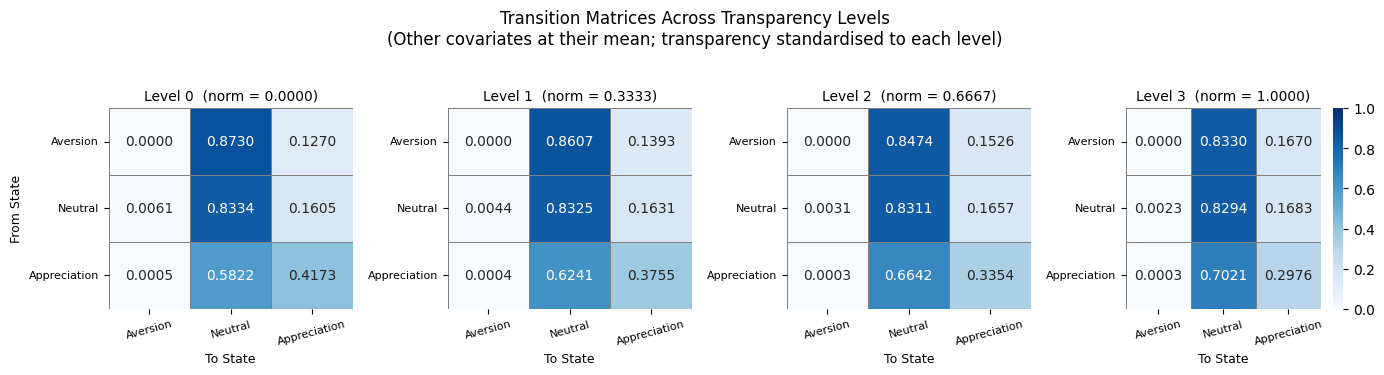


Transition matrices by transparency level (display order):

  Level 0 (norm = 0.0000):
    From Aversion: [0.    0.873 0.127]
    From Neutral: [0.0061 0.8334 0.1605]
    From Appreciation: [5.000e-04 5.822e-01 4.173e-01]

  Level 1 (norm = 0.3333):
    From Aversion: [0.     0.8607 0.1393]
    From Neutral: [0.0044 0.8325 0.1631]
    From Appreciation: [4.000e-04 6.241e-01 3.755e-01]

  Level 2 (norm = 0.6667):
    From Aversion: [0.     0.8474 0.1526]
    From Neutral: [0.0031 0.8311 0.1657]
    From Appreciation: [3.000e-04 6.642e-01 3.354e-01]

  Level 3 (norm = 1.0000):
    From Aversion: [0.    0.833 0.167]
    From Neutral: [0.0023 0.8294 0.1683]
    From Appreciation: [3.000e-04 7.021e-01 2.976e-01]


In [37]:

# ============================================================
# Transition Probabilities Under Alternative Transparency Levels
#
#   For each transparency level t in {0, 1, 2, 3}:
#     t_norm = t / 3.0   (raw normalized value)
#     x[t_idx] = (t_norm - x_sc.mean_[t_idx]) / x_sc.scale_[t_idx]
#               (standardised, as the model was fit on standardised X)
#     Other covariates held at 0 in standardised space (= their mean).
#     logits[i,j] = alpha[i,j] + sum_p beta[i,j,p] * x[p]
#     Q(t)[i,:] = softmax(logits[i,:])
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from IPython.display import display, HTML

# -- 0. Model parameters -------------------------------------
_alpha = best_model.alpha           # (J, J)
_beta  = best_model.beta            # (J, J, P)
_J     = int(best_J)
_P     = _beta.shape[2]

# Covariate index for transparency_level_norm (always last = P-1)
_t_idx = _P - 1

# Standardisation parameters for transparency_level_norm
_t_mean  = float(x_sc.mean_[_t_idx])
_t_scale = float(x_sc.scale_[_t_idx])

# State labels in display order
_labels = [label_map[s] for s in state_order_1idx]

# -- helpers --------------------------------------------------
def sig_stars(pv):
    if pd.isna(pv):
        return ""
    if pv < 0.001:
        return "***"
    if pv < 0.01:
        return "**"
    if pv < 0.05:
        return "*"
    if pv < 0.10:
        return "\u2020"
    return ""

def build_transition_mats(alpha_mat, beta_tens, J, P, t_idx, t_mean, t_scale, levels):
    out = {}
    for t_raw in levels:
        t_norm = t_raw / 3.0
        x = np.zeros(P)
        x[t_idx] = (t_norm - t_mean) / t_scale
        Q_t = np.zeros((J, J))
        for i in range(J):
            logits = alpha_mat[i] + beta_tens[i] @ x
            Q_t[i] = softmax(logits)
        out[t_raw] = Q_t
    return out

# -- 1. Compute Q at each transparency level -----------------
transparency_levels = [0, 1, 2, 3]
trans_matrices = build_transition_mats(
    _alpha, _beta, _J, _P, _t_idx, _t_mean, _t_scale, transparency_levels
)

# -- 2. Heatmap grid -----------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))

for ax, t_raw in zip(axes, transparency_levels):
    Q_t = trans_matrices[t_raw]

    # Reorder to display order
    Q_disp = Q_t[np.ix_(
        [s - 1 for s in state_order_1idx],
        [s - 1 for s in state_order_1idx]
    )]

    sns.heatmap(
        Q_disp,
        ax=ax,
        annot=True,
        fmt=".4f",
        cmap="Blues",
        vmin=0.0, vmax=1.0,
        xticklabels=_labels,
        yticklabels=_labels,
        cbar=(t_raw == 3),
        linewidths=0.5,
        linecolor="grey",
    )
    ax.set_title(
        f"Level {t_raw}  (norm = {t_raw/3:.4f})",
        fontsize=10, pad=6
    )
    ax.set_xlabel("To State", fontsize=9)
    ax.set_ylabel("From State" if t_raw == 0 else "", fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=15)
    ax.tick_params(axis="y", labelsize=8, rotation=0)

fig.suptitle(
    "Transition Matrices Across Transparency Levels\n"
    "(Other covariates at their mean; transparency standardised to each level)",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()

# -- 3. Summary table ----------------------------------------
rows = []
for t_raw in transparency_levels:
    Q_t = trans_matrices[t_raw]
    for i in range(_J):
        from_label = label_map[state_order_1idx[i]]
        for j in range(_J):
            to_label = label_map[state_order_1idx[j]]
            rows.append({
                "Transparency Level": t_raw,
                "norm (= level/3)": f"{t_raw/3:.4f}",
                "From State": from_label,
                "To State": to_label,
                "Transition Prob.": round(
                    float(Q_t[state_order_1idx[i] - 1, state_order_1idx[j] - 1]), 4
                ),
            })

trans_df = pd.DataFrame(rows)

# -- 4. Bootstrap significance for DeltaP vs Level 0 ---------
sig_lookup = {}
sig_note = "Significance unavailable (bootstrap objects not found)."

have_boot = all(k in globals() for k in ["boot_delta", "v0", "alpha_sl", "beta_sl"])
if have_boot:
    B_eff = min(int(len(boot_delta)), 1000)
    delta_draws = {
        (t_raw, i, j): np.empty(B_eff, dtype=float)
        for t_raw in transparency_levels[1:]
        for i in range(_J)
        for j in range(_J)
    }

    for b in range(B_eff):
        theta_b = v0 + boot_delta[b]
        alpha_b = theta_b[alpha_sl].reshape(_J, _J)
        beta_b = theta_b[beta_sl].reshape(_J, _J, _P)
        mats_b = build_transition_mats(
            alpha_b, beta_b, _J, _P, _t_idx, _t_mean, _t_scale, transparency_levels
        )
        Q0_b = mats_b[0]
        for t_raw in transparency_levels[1:]:
            Qt_b = mats_b[t_raw]
            for i in range(_J):
                for j in range(_J):
                    p0 = Q0_b[state_order_1idx[i] - 1, state_order_1idx[j] - 1]
                    pt = Qt_b[state_order_1idx[i] - 1, state_order_1idx[j] - 1]
                    delta_draws[(t_raw, i, j)][b] = float(pt - p0)

    for t_raw in transparency_levels[1:]:
        for i in range(_J):
            from_label = label_map[state_order_1idx[i]]
            for j in range(_J):
                to_label = label_map[state_order_1idx[j]]
                p0_obs = float(trans_matrices[0][state_order_1idx[i] - 1, state_order_1idx[j] - 1])
                pt_obs = float(trans_matrices[t_raw][state_order_1idx[i] - 1, state_order_1idx[j] - 1])
                d_obs = pt_obs - p0_obs
                d_boot = delta_draws[(t_raw, i, j)]

                p_two = 2.0 * min(np.mean(d_boot >= 0.0), np.mean(d_boot <= 0.0))
                p_two = float(min(max(p_two, 0.0), 1.0))

                sig_lookup[(from_label, to_label, t_raw)] = {
                    "delta_obs": d_obs,
                    "p": p_two,
                    "stars": sig_stars(p_two),
                }

    sig_note = f"Significance from bootstrap DeltaP vs Level 0 (B={B_eff})."

# -- 5. Pivot for compact view with significance -------------
pivot_base = trans_df.pivot_table(
    index=["From State", "To State"],
    columns="Transparency Level",
    values="Transition Prob.",
)

pivot_rows = []
for (from_state, to_state), vals in pivot_base.iterrows():
    row = {
        "From State": from_state,
        "To State": to_state,
        "L0  (norm=0.0000)": f"{float(vals.get(0, np.nan)):.4f}",
    }
    for t_raw in [1, 2, 3]:
        p_t = float(vals.get(t_raw, np.nan))
        base_txt = f"{p_t:.4f}"
        if (from_state, to_state, t_raw) in sig_lookup:
            star = sig_lookup[(from_state, to_state, t_raw)]["stars"]
            pval = sig_lookup[(from_state, to_state, t_raw)]["p"]
            ptxt = f"{pval:.3f}" if pval >= 0.001 else "<0.001"
            row[f"L{t_raw}  (norm={t_raw/3:.4f})"] = f"{base_txt}{star} (p={ptxt})"
        else:
            row[f"L{t_raw}  (norm={t_raw/3:.4f})"] = base_txt
    pivot_rows.append(row)

pivot_trans = pd.DataFrame(pivot_rows)

html_parts = []
html_parts.append(
    "<h4>Transition Probabilities Under Alternative Transparency Levels</h4>"
    "<p style='font-size:0.85em;color:#555;'>"
    "Transition probabilities Q(t)[i→j] = softmax(alpha[i] + beta[i,j,:]·x) with "
    "x[transparency] = (t/3 - mean) / sd (standardised as in model estimation), "
    "all other covariates held at 0 in standardised space (= their sample mean). "
    "Each column corresponds to one of the four experimental transparency levels.</p>"
)
html_parts.append(
    pivot_trans.to_html(index=False, border=1, classes="table table-sm", escape=False)
)

# -- 6. Change in transition probability relative to Level 0 -
rows_delta = []
Q0 = trans_matrices[0]
for t_raw in transparency_levels[1:]:
    Qt = trans_matrices[t_raw]
    for i in range(_J):
        from_label = label_map[state_order_1idx[i]]
        for j in range(_J):
            to_label = label_map[state_order_1idx[j]]
            p0 = float(Q0[state_order_1idx[i] - 1, state_order_1idx[j] - 1])
            pt = float(Qt[state_order_1idx[i] - 1, state_order_1idx[j] - 1])
            d = round(pt - p0, 4)
            if (from_label, to_label, t_raw) in sig_lookup:
                stars = sig_lookup[(from_label, to_label, t_raw)]["stars"]
                pv = sig_lookup[(from_label, to_label, t_raw)]["p"]
                ptxt = f"{pv:.3f}" if pv >= 0.001 else "<0.001"
                d_txt = f"{d:+.4f}{stars} (p={ptxt})"
            else:
                d_txt = f"{d:+.4f}"
            rows_delta.append({
                "From → To": f"{from_label} → {to_label}",
                f"DeltaP at L{t_raw} vs L0": d_txt,
            })

changes_data = []
pair_labels = list(dict.fromkeys(r["From → To"] for r in rows_delta))
for pair in pair_labels:
    r = {"From → To": pair}
    for t_raw in transparency_levels[1:]:
        key = f"DeltaP at L{t_raw} vs L0"
        match = [x[key] for x in rows_delta if x["From → To"] == pair and key in x]
        r[key] = match[0] if match else np.nan
    changes_data.append(r)

changes_df = pd.DataFrame(changes_data)

html_parts.append(
    "<br><b>Change in transition probability relative to Level 0 (DeltaP = P(L_k) - P(L_0))</b>"
)
html_parts.append(
    changes_df.to_html(index=False, border=1, classes="table table-sm", na_rep="-", escape=False)
)
html_parts.append(
    "<p style='font-size:0.80em;color:#888;'>"
    "Positive DeltaP means transparency level k makes that transition more likely than Level 0. "
    + sig_note + " Star legend: *** p&lt;0.001, ** p&lt;0.01, * p&lt;0.05, \u2020 p&lt;0.10."
    "</p>"
)

display(HTML("\n".join(html_parts)))

# Quick console summary
print("\nTransition matrices by transparency level (display order):")
for t_raw in transparency_levels:
    Q_t = trans_matrices[t_raw]
    Q_disp = Q_t[np.ix_(
        [s - 1 for s in state_order_1idx],
        [s - 1 for s in state_order_1idx]
    )]
    print(f"\n  Level {t_raw} (norm = {t_raw/3:.4f}):")
    for i, fl in enumerate(_labels):
        print(f"    From {fl}: {np.round(Q_disp[i], 4)}")


In [38]:
# Prep for 3-state KPI sensitivity and downstream plots
# Preserve model-aware state ordering/labels when already computed.
import numpy as np

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

if "state_order_1idx" in globals() and state_order_1idx is not None and len(state_order_1idx) >= best_J:
    state_order_1idx = list(state_order_1idx)[:best_J]
else:
    if "mu_orig" in globals():
        mu_arr = mu_orig
    elif "mu_orig_" in globals():
        mu_arr = mu_orig_
    else:
        mu_arr = best_model.mu

    authority_idx = 0
    order_0 = list(np.argsort(mu_arr[:, authority_idx]))
    state_order_1idx = [s + 1 for s in order_0]

if "label_map" not in globals() or label_map is None:
    label_map = {}

# Force canonical rank labels for J=3 ordering used in this workbook section.
expected = ["Aversion", "Neutral", "Appreciation"]
for i, s in enumerate(state_order_1idx[:3]):
    label_map[s] = expected[i]

print("Prepared state order:", state_order_1idx)
print("Prepared labels:", [label_map[s] for s in state_order_1idx])

Prepared state order: [3, 1, 2]
Prepared labels: ['Aversion', 'Neutral', 'Appreciation']


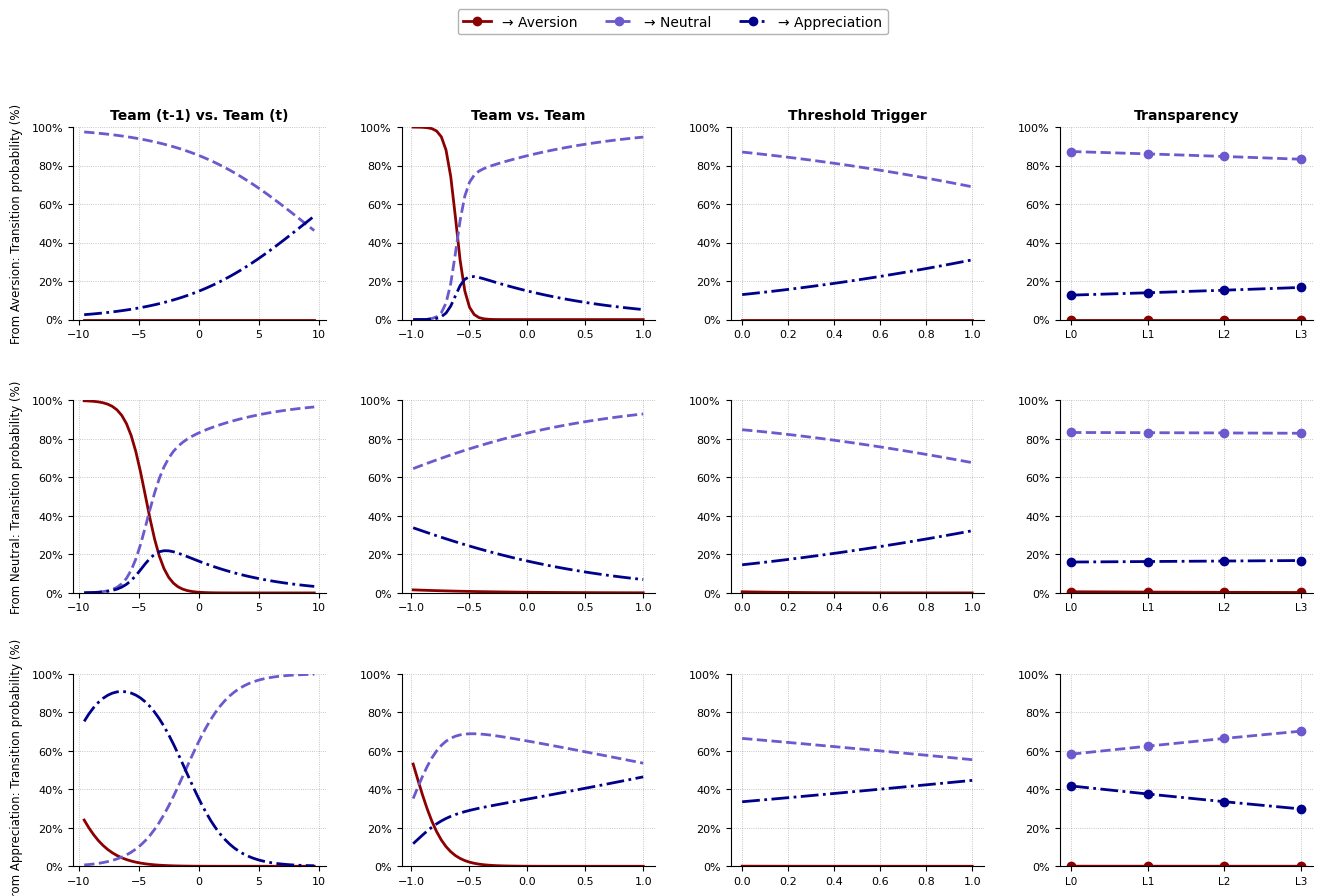

✔ Saved: kpi_sensitivity_analysis_misq.png


In [39]:
# ============================================================
# KPI-Driven Sensitivity Analysis  —  State-Transition Line Plots
#   3-state ready (Aversion, Neutral, Appreciation)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.lines as mlines
from scipy.special import softmax

_alpha = best_model.alpha
_beta = best_model.beta
_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)
_P = _beta.shape[2]

assert "state_order_1idx" in globals() and state_order_1idx is not None, "state_order_1idx missing"
assert "label_map" in globals() and label_map is not None, "label_map missing"

state_order_1idx = list(state_order_1idx)[:_J]
_labels = [label_map[s] for s in state_order_1idx]
_idx = [s - 1 for s in state_order_1idx]

x_cols = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
]
x_nice = [
    "Team (t-1) vs. Team (t)",
    "Team vs. Team",
    "Threshold Trigger",
    "Transparency",
]

_n_grid = 50
_pal = ["#8B0000", "#6A5ACD", "#00008B", "#2E8B57"]
_ls_dest = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(
    len(_idx),
    len(x_cols),
    figsize=(16, 3.2 * len(_idx)),
    sharey=False,
    gridspec_kw={"hspace": 0.42, "wspace": 0.30},
)
axes = np.atleast_2d(axes)

for col_idx, (col, nice) in enumerate(zip(x_cols, x_nice)):
    p_idx = col_idx
    mu_p = float(x_sc.mean_[p_idx])
    sd_p = float(x_sc.scale_[p_idx])

    col_raw = df[col].dropna().values
    z_lo = float((col_raw.min() - mu_p) / sd_p)
    z_hi = float((col_raw.max() - mu_p) / sd_p)

    is_transparency = (col == "transparency_level_norm")

    if is_transparency:
        raw_grid = np.array([0, 1/3, 2/3, 1.0])
        z_grid = (raw_grid - mu_p) / sd_p
    else:
        z_grid = np.linspace(z_lo, z_hi, _n_grid)
        raw_grid = z_grid * sd_p + mu_p

    for row_idx, (from_0idx, from_label_r) in enumerate(zip(_idx, _labels)):
        ax = axes[row_idx, col_idx]

        for dest_i, (to_0idx, to_label) in enumerate(zip(_idx, _labels)):
            probs = []
            for z in z_grid:
                xv = np.zeros(_P)
                xv[p_idx] = z
                logits = _alpha[from_0idx] + _beta[from_0idx] @ xv
                q_row = softmax(logits)
                probs.append(q_row[to_0idx])

            ax.plot(
                np.arange(4) if is_transparency else raw_grid,
                [p * 100 for p in probs],
                color=_pal[dest_i],
                ls=_ls_dest[dest_i],
                lw=2.0,
                marker="o" if is_transparency else None,
                markersize=6 if is_transparency else 0,
            )

        ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
        ax.set_ylim(0, 100)
        ax.set_yticks(range(0, 101, 20))
        ax.grid(True, ls=":", lw=0.6, color="gray", alpha=0.6)
        ax.tick_params(labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

        if row_idx == 0:
            ax.set_title(nice, fontsize=10, pad=6, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(f"From {from_label_r}: Transition probability (%)", fontsize=8.5, labelpad=6)

        if is_transparency:
            ax.set_xticks([0, 1, 2, 3])
            ax.set_xticklabels(["L0", "L1", "L2", "L3"], fontsize=7.5)

legend_handles = [
    mlines.Line2D([], [], color=_pal[i], ls=_ls_dest[i], lw=2.0,
                  marker="o", markersize=6, label=f"→ {_labels[i]}")
    for i in range(len(_labels))
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=len(_labels),
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor="#aaa",
    bbox_to_anchor=(0.5, 1.01),
)

plt.savefig("kpi_sensitivity_analysis_misq.png", dpi=200, bbox_inches="tight")
plt.show()
print("✔ Saved: kpi_sensitivity_analysis_misq.png")

## State distribution over time

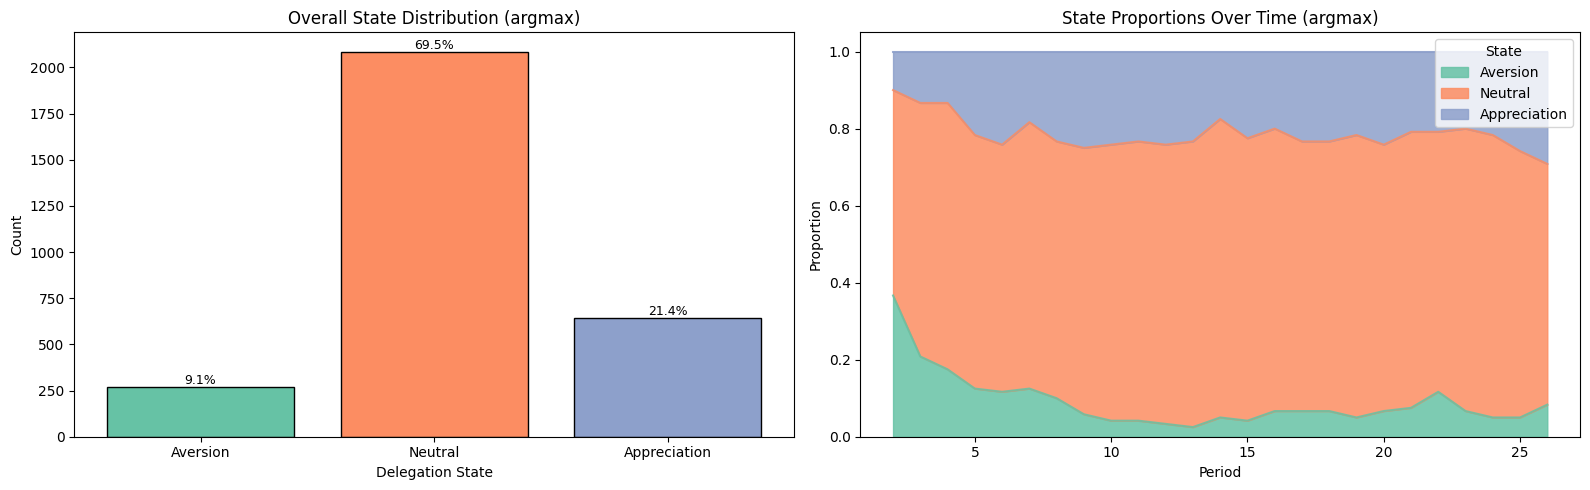

In [40]:
# ============================================================
# 4.2a. State distribution over time (3-state ready)
#   - Uses label_map + state_order_1idx
#   - Order shown: Aversion → Neutral → Appreciation
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."
assert "posteriors" in globals(), "posteriors not found. Run the posterior assignment cell first."

posteriors = posteriors.copy()
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

label_order = [label_map[s] for s in list(state_order_1idx)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

freq_labeled = (
    posteriors["state_label"]
    .value_counts()
    .reindex(label_order)
    .fillna(0)
)

axes[0].bar(
    label_order,
    freq_labeled.values,
    color=sns.color_palette("Set2", len(label_order)),
    edgecolor="k"
)
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution (argmax)")

total_n = float(freq_labeled.sum())
for i, val in enumerate(freq_labeled.values):
    pct = (val / total_n * 100.0) if total_n > 0 else 0.0
    axes[0].text(i, val, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.85,
    color=sns.color_palette("Set2", len(label_order)),
)

axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time (argmax)")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()

## Average of AI authority share and escalation rate

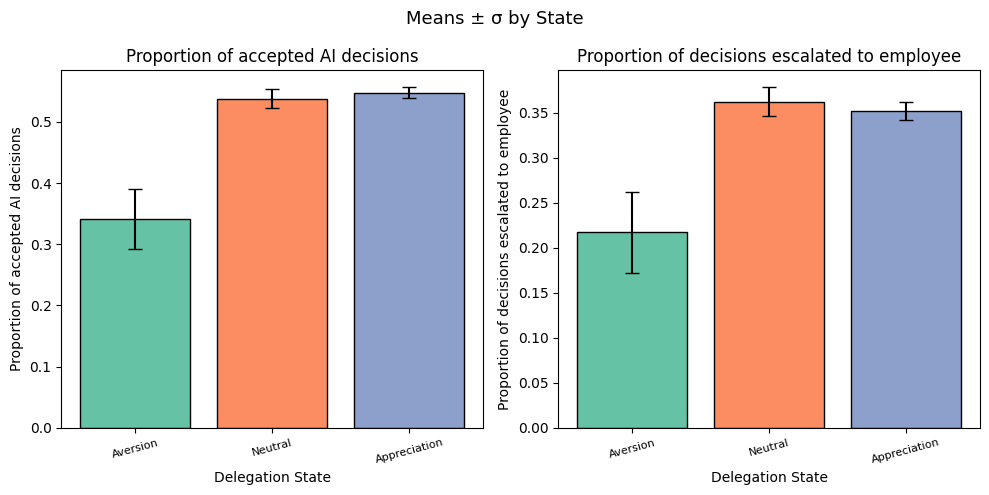

In [41]:
# ============================================================
# 4.2b. Emission means by state (original scale) — 3-state version
#   - Only the 2 independent emission dimensions
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

mu_arr = mu_orig if "mu_orig" in globals() else (mu_orig_ if "mu_orig_" in globals() else best_model.mu)
sig_arr = sigma_orig if "sigma_orig" in globals() else (sigma_orig_ if "sigma_orig_" in globals() else np.exp(best_model.log_sigma))

independent_dims = {
    0: ("ai_decision_authority_share", "Proportion of accepted AI decisions"),
    1: ("share_authority_esc", "Proportion of decisions escalated to employee"),
}

n_panels = len(independent_dims)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
axes = np.atleast_1d(axes)

state_order_1idx = list(state_order_1idx)[:best_J]
state_order_0idx = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

palette = sns.color_palette("Set2", len(label_order))

for ax_idx, (d, (col, nice_name)) in enumerate(independent_dims.items()):
    ax = axes[ax_idx]

    vals = [mu_arr[s, d] for s in state_order_0idx]
    errs = [sig_arr[s, d] for s in state_order_0idx]

    ax.bar(label_order, vals, yerr=errs, capsize=5, color=palette, edgecolor="k")
    ax.set_xlabel("Delegation State")
    ax.set_ylabel(nice_name)
    ax.set_title(nice_name)
    ax.tick_params(axis="x", labelsize=8, rotation=15)

plt.suptitle("Means ± σ by State", fontsize=13)
plt.tight_layout()
plt.show()

## Appreciation - Aversion Transition dynamics

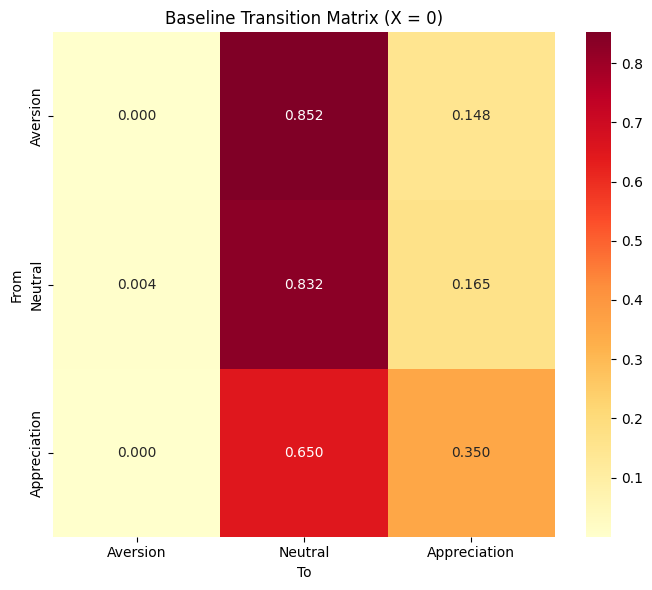


Transition probabilities (rows sum to 1):
  From Aversion: [0.000 0.852 0.148]
  From Neutral: [0.004 0.832 0.165]
  From Appreciation: [0.000 0.650 0.350]


In [42]:
# ============================================================
# 4.2c. Transition matrix heatmap (baseline, at X=0) â€” 3-state version
#   - Uses your computed label_map + state_order_1idx
#   - Displays in order: Aversion â†’ Transitionary â†’ Appreciation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# ---- Baseline transition matrix at X=0 ----
Q_base = np.zeros((best_J, best_J))
for j in range(best_J):
    logits = best_model.alpha[j]
    Q_base[j] = softmax(logits)

# ---- Display order: Aversion â†’ Transitionary â†’ Appreciation ----
state_display_order = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

Q_base_ordered = Q_base[np.ix_(state_display_order, state_display_order)]

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    Q_base_ordered,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Baseline Transition Matrix (X = 0)")
plt.tight_layout()
plt.show()

# ---- Print formatted rows ----
print("\nTransition probabilities (rows sum to 1):")
for i, from_label in enumerate(label_order):
    from_state = state_display_order[i]
    probs = " ".join(f"{Q_base[from_state, state_display_order[j]]:.3f}" for j in range(best_J))
    print(f"  From {from_label}: [{probs}]")


## KPI driven transition dynamic

Detected transition covariates in model: P = 4
Transition covariate labels used: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'threshold_benchmark', 'transparency_level_norm']
⚠️ x_scaler.scale_ not available or dimension mismatch → skipping unscale.

═══  Transition Covariate Coefficients (β)  ═══


── β coefficients (scaled X): within_unit_temporal_benchmark ──


To,Aversion,Neutral,Appreciation
From,,,
Aversion,-0.3866,0.0180,0.4015
Neutral,-1.5766,0.9575,0.6083
Appreciation,-1.1417,1.0943,0.0208



── β coefficients (scaled X): horizontal_peer_benchmark ──


To,Aversion,Neutral,Appreciation
From,,,
Aversion,-8.7724,4.7461,4.0762
Neutral,-0.4947,0.5256,-0.0408
Appreciation,-3.1642,1.4458,1.7239



── β coefficients (scaled X): threshold_benchmark ──


To,Aversion,Neutral,Appreciation
From,,,
Aversion,-1.5550,0.5883,0.9676
Neutral,-0.9788,0.3159,0.6657
Appreciation,-0.8907,0.3653,0.5261



═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══



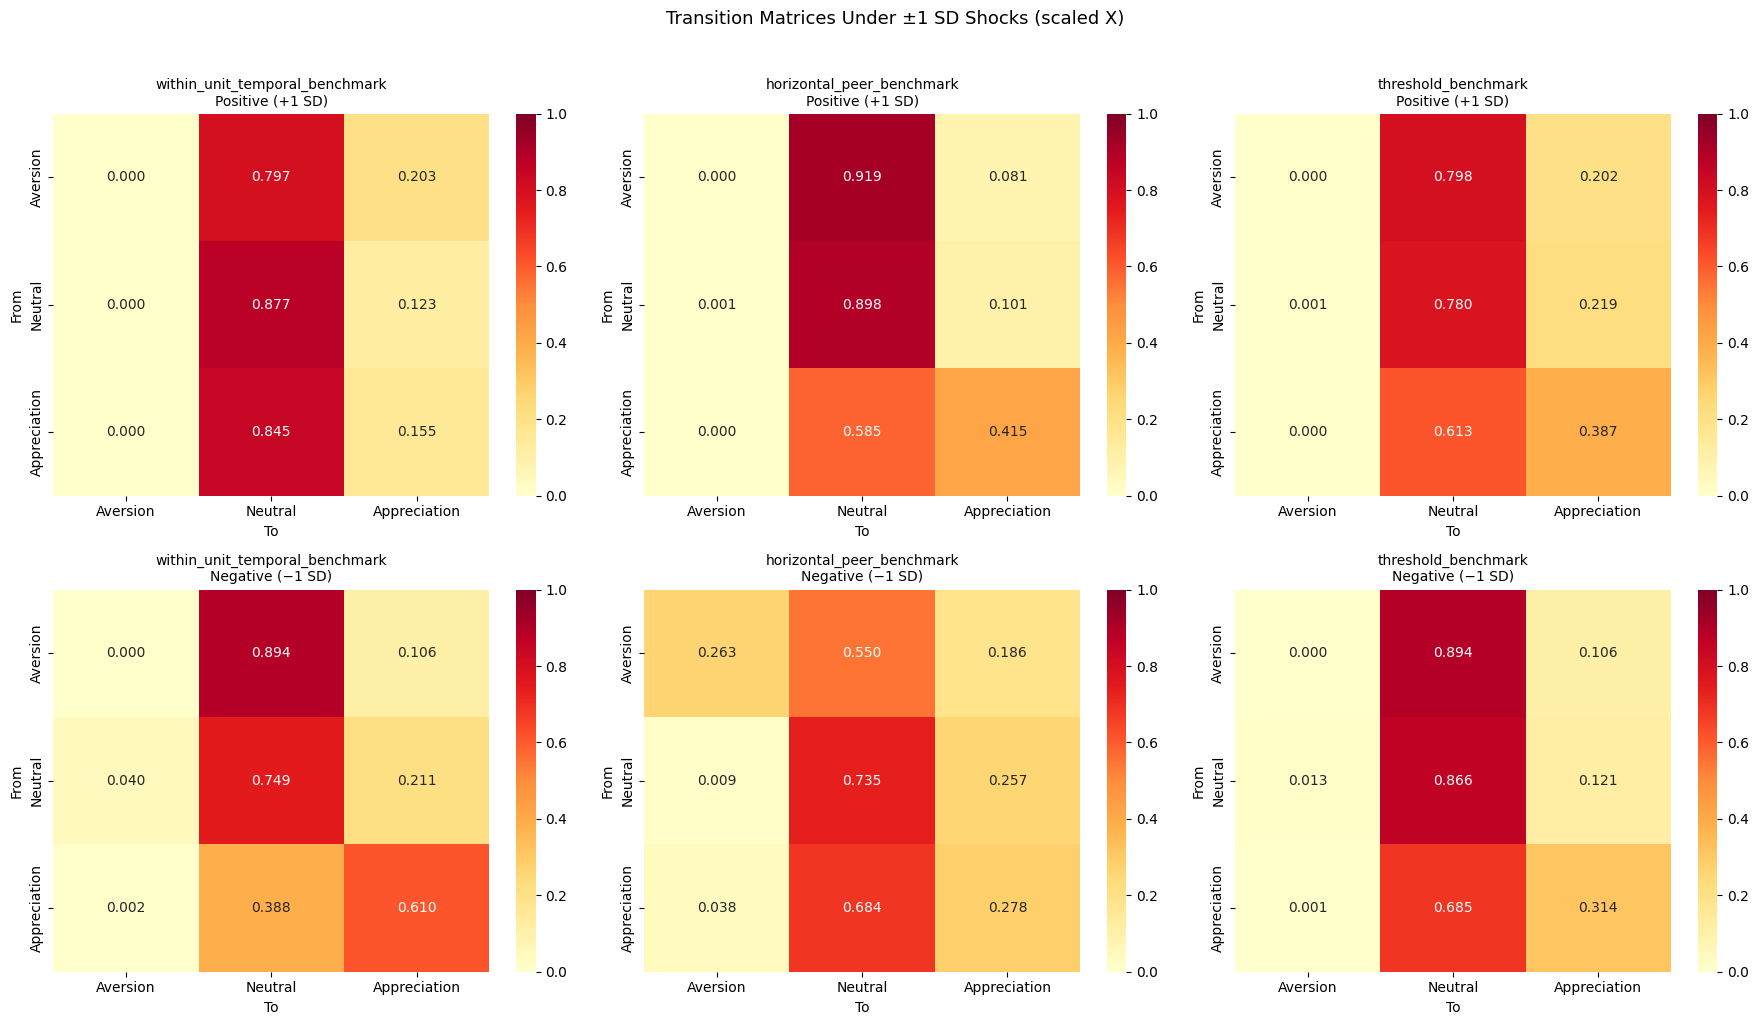


═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══



,Covariate,Shock,Avg ΔP(→Aversion),Avg ΔP(→Appreciation),Avg ΔP(→Transitionary)
0,within_unit_temporal_benchmark,Positive (+1SD),-0.0012,-0.0605,0.0617
1,within_unit_temporal_benchmark,Negative (−1SD),0.0128,0.0881,-0.1009
2,horizontal_peer_benchmark,Positive (+1SD),-0.0008,-0.0215,0.0223
3,horizontal_peer_benchmark,Negative (−1SD),0.1020,0.0197,-0.1217
4,threshold_benchmark,Positive (+1SD),-0.0010,0.0488,-0.0478
5,threshold_benchmark,Negative (−1SD),0.0036,-0.0405,0.0369



✓ Result 5.1.2: Transition coefficients and shock simulations for 3 states.


In [43]:
# ============================================================
# KPI-Driven State Transitions (J-aware: works for J=2 or J=3)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

assert "label_map" in globals(), "label_map not found. Run STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run STATE LABELING cell first."

# Display order: Aversion → [Transitionary →] Appreciation
state_display_order_0 = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

aversion_idx0      = state_display_order_0[0]
appreciation_idx0  = state_display_order_0[-1]   # works for J=2 and J=3
transitionary_idx0 = state_display_order_0[1] if len(state_display_order_0) > 2 else None

# ------------------------------------------------------------
# 0) Infer P from the fitted model
# ------------------------------------------------------------
beta = best_model.beta
assert beta.ndim == 3, f"Expected beta to be 3D (J,J,P). Got {beta.shape}."
P_model = beta.shape[2]
print(f"Detected transition covariates in model: P = {P_model}")

transition_cols_full = (
    list(transition_cols_model)
    if "transition_cols_model" in globals() and transition_cols_model is not None
    else [
        "within_unit_temporal_benchmark",
        "horizontal_peer_benchmark",
        "threshold_benchmark",
        "transparency_level_norm",
        "transparency_x_operational",
        "transparency_x_temporal",
    ]
)

if P_model <= len(transition_cols_full):
    transition_cols = transition_cols_full[:P_model]
else:
    transition_cols = transition_cols_full + [f"x_cov_{i}" for i in range(len(transition_cols_full), P_model)]

print("Transition covariate labels used:", transition_cols)

# Unscale if scaler matches P
if hasattr(data, "x_scaler") and hasattr(data.x_scaler, "scale_") and len(data.x_scaler.scale_) == P_model:
    beta_orig = beta / data.x_scaler.scale_[None, None, :]
    have_unscale = True
else:
    beta_orig = beta.copy()
    have_unscale = False
    print("⚠️ x_scaler.scale_ not available or dimension mismatch → skipping unscale.")

# ------------------------------------------------------------
# a) Beta coefficient table
# ------------------------------------------------------------
print("\n═══  Transition Covariate Coefficients (β)  ═══\n")
beta_rows = []
for p_idx, cov in enumerate(transition_cols):
    for from_pos, from_label in enumerate(label_order):
        i0 = state_display_order_0[from_pos]
        for to_pos, to_label in enumerate(label_order):
            j0 = state_display_order_0[to_pos]
            row = {
                "Covariate": cov,
                "From": from_label,
                "To": to_label,
                "β (scaled)": round(float(beta[i0, j0, p_idx]), 4),
            }
            if have_unscale:
                row["β (orig units)"] = round(float(beta_orig[i0, j0, p_idx]), 4)
            beta_rows.append(row)

beta_df = pd.DataFrame(beta_rows)

# Print pivots for up to 3 covariates
for cov in transition_cols[:3]:
    sub = beta_df[beta_df["Covariate"] == cov].pivot(index="From", columns="To", values="β (scaled)")
    print(f"\n── β coefficients (scaled X): {cov} ──")
    display(sub.reindex(index=label_order, columns=label_order).round(4))

# ------------------------------------------------------------
# b) Simulated transition matrices at ±1 SD of KPI (scaled space)
# ------------------------------------------------------------
print("\n═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══\n")

kpi_covariates = [(transition_cols[i], i) for i in range(min(3, P_model))]
n_cov = len(kpi_covariates)

fig, axes = plt.subplots(2, n_cov, figsize=(6*n_cov, 10), squeeze=False)

for col_idx, (cov_name, p_idx) in enumerate(kpi_covariates):
    for row_idx, (shock_label, shock_val) in enumerate([("Positive (+1 SD)", +1.0),
                                                         ("Negative (−1 SD)", -1.0)]):
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        Q_shock = np.zeros((best_J, best_J))
        for i0 in range(best_J):
            logits = best_model.alpha[i0] + best_model.beta[i0] @ x_vec
            Q_shock[i0] = softmax(logits)

        Q_shock_ordered = Q_shock[np.ix_(state_display_order_0, state_display_order_0)]

        ax = axes[row_idx, col_idx]
        sns.heatmap(
            Q_shock_ordered,
            annot=True,
            fmt=".3f",
            cmap="YlOrRd",
            xticklabels=label_order,
            yticklabels=label_order,
            ax=ax,
            vmin=0,
            vmax=1.0
        )
        ax.set_title(f"{cov_name}\n{shock_label}", fontsize=10)
        ax.set_xlabel("To")
        ax.set_ylabel("From")

plt.suptitle("Transition Matrices Under ±1 SD Shocks (scaled X)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# c) Asymmetry quantification
# ------------------------------------------------------------
print("\n═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══\n")

asym_rows = []
for cov_name, p_idx in kpi_covariates:
    for shock_label, shock_val in [("Positive (+1SD)", +1.0), ("Negative (−1SD)", -1.0)]:
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        d_to_av, d_to_trans, d_to_app = [], [], []
        for i0 in range(best_J):
            p_base  = softmax(best_model.alpha[i0])
            p_shock = softmax(best_model.alpha[i0] + best_model.beta[i0] @ x_vec)

            d_to_av.append(p_shock[aversion_idx0] - p_base[aversion_idx0])
            if transitionary_idx0 is not None:
                d_to_trans.append(p_shock[transitionary_idx0] - p_base[transitionary_idx0])
            d_to_app.append(p_shock[appreciation_idx0] - p_base[appreciation_idx0])

        row = {
            "Covariate": cov_name,
            "Shock": shock_label,
            "Avg ΔP(→Aversion)": round(float(np.mean(d_to_av)), 4),
            "Avg ΔP(→Appreciation)": round(float(np.mean(d_to_app)), 4),
        }
        if transitionary_idx0 is not None:
            row["Avg ΔP(→Transitionary)"] = round(float(np.mean(d_to_trans)), 4)
        asym_rows.append(row)

asym_df = pd.DataFrame(asym_rows)
display(asym_df)

print(f"\n✓ Result 5.1.2: Transition coefficients and shock simulations for {best_J} states.")

## Transparency effects on transition dynamics

═══  Transparency Effects on State Transitions  ═══

Model P = 4 transition covariates
Transition covariates: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'threshold_benchmark', 'transparency_level_norm']
  transparency_level_norm index : 3



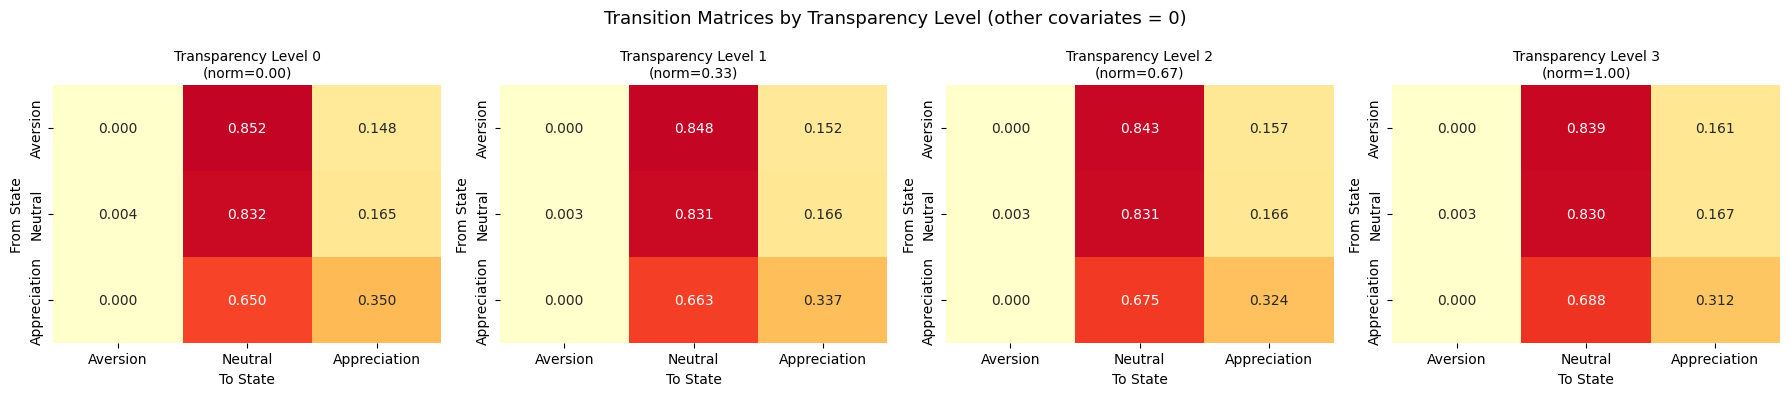


═══  Transition Probability Changes vs Level 0  ═══

── Δ P  (Level 1 − Level 0) ──


To,Aversion,Neutral,Appreciation
From,,,
Aversion,0.0000,-0.0044,0.0044
Neutral,-0.0004,-0.0005,0.0008
Appreciation,-0.0000,0.0128,-0.0128


── Δ P  (Level 2 − Level 0) ──


To,Aversion,Neutral,Appreciation
From,,,
Aversion,0.0000,-0.0090,0.0090
Neutral,-0.0007,-0.0010,0.0017
Appreciation,-0.0000,0.0254,-0.0254


── Δ P  (Level 3 − Level 0) ──


To,Aversion,Neutral,Appreciation
From,,,
Aversion,0.0000,-0.0136,0.0136
Neutral,-0.0010,-0.0016,0.0025
Appreciation,-0.0001,0.0378,-0.0377


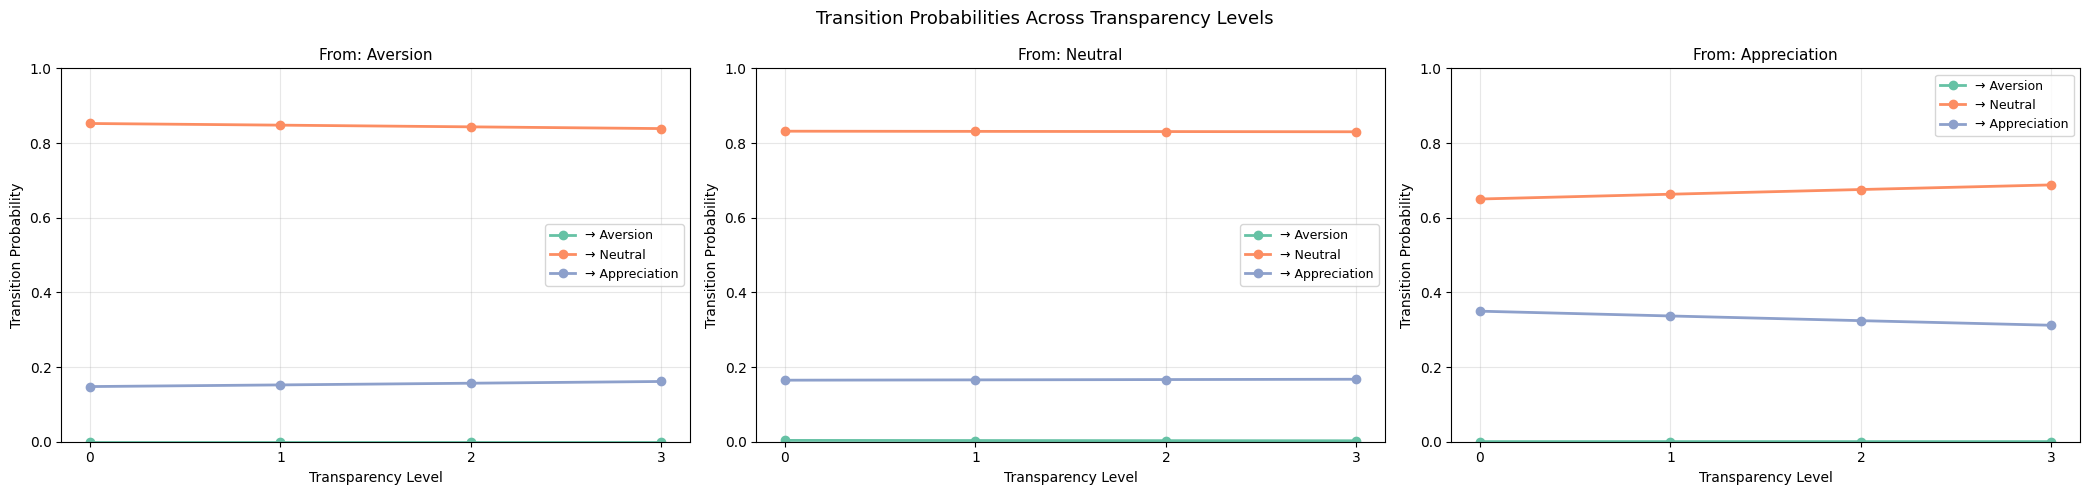

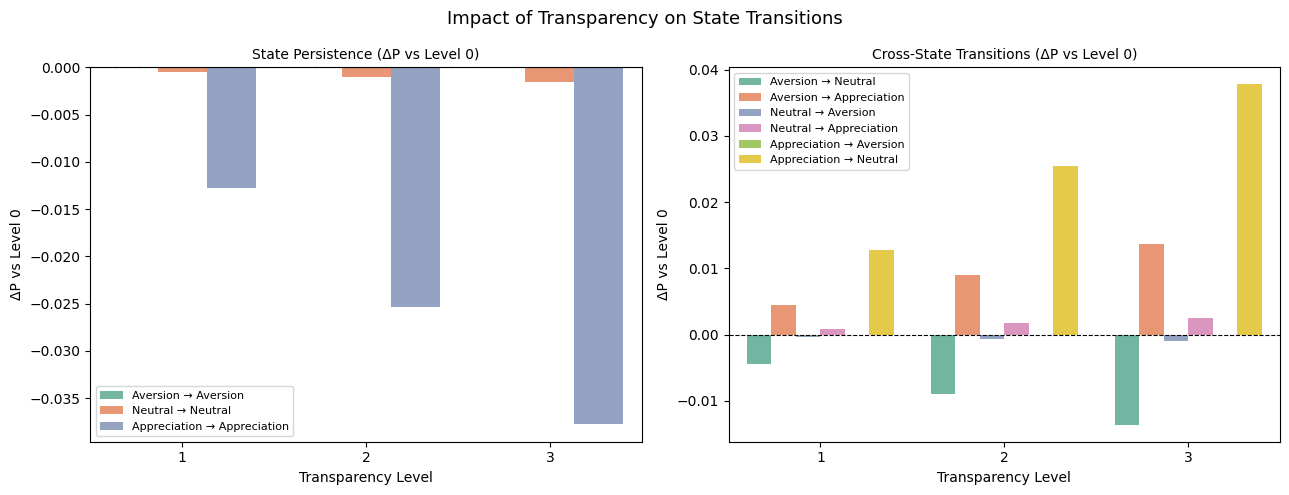


═══  β Coefficients for Transparency Covariates  ═══

── transparency_level_norm (index 3) ──


To,Aversion,Neutral,Appreciation
From,,,
Aversion,0.2759,-0.1953,-0.091
Neutral,-0.2213,0.0987,0.1158
Appreciation,-0.108,0.1413,-0.0293



═══  Summary: Average |ΔP| by Transparency Level  ═══



,Mean |ΔP|,Max |ΔP|
Transparency Level,,
1,0.004,0.0128
2,0.008,0.0254
3,0.012,0.0378



✓ Transparency analysis complete. Levels 0–3; transparency_level_norm at index 3.


In [44]:

# ============================================================
# Transparency Effects on Transition Dynamics (4-level analysis)
#   - Computes transition matrices at each transparency level (0–3)
#   - Uses fitted beta coefficients for transparency_level_norm
#     (other covariates held at zero = mean of scaled data)
#   - Compares changes relative to Level 0 baseline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from IPython.display import display

print("═══  Transparency Effects on State Transitions  ═══\n")

# —— Fitted parameters ————————————————————————————————
J_t    = int(best_J)
alpha  = best_model.alpha   # (J, J)
beta_t = best_model.beta    # (J, J, P)
P_t    = beta_t.shape[2]

trans_cov_names = (
    list(transition_cols_model)
    if "transition_cols_model" in globals() and transition_cols_model is not None
    else [
        "within_unit_temporal_benchmark",
        "horizontal_peer_benchmark",
        "threshold_benchmark",
        "transparency_level_norm",
        "transparency_x_operational",
        "transparency_x_temporal",
    ]
)
trans_cov_names = trans_cov_names[:P_t]

def _idx(name):
    return trans_cov_names.index(name) if name in trans_cov_names else None

trans_main_idx = _idx("transparency_level_norm")
trans_cov_idxs = [(nm, i) for i, nm in enumerate(trans_cov_names) if "transparency" in nm]

print(f"Model P = {P_t} transition covariates")
print("Transition covariates:", trans_cov_names)
print(f"  transparency_level_norm index : {trans_main_idx}")
for nm, i in trans_cov_idxs:
    if nm != "transparency_level_norm":
        print(f"  {nm} index : {i}")
print()

# —— State display order —————————————————————————————
state_labels  = [label_map[s] for s in state_order_1idx]
state_order_0 = [s - 1 for s in state_order_1idx]

# —— 1. Transition matrices at each transparency level ———
transparency_levels = [0, 1, 2, 3]
transparency_norm   = [t / 3.0 for t in transparency_levels]

trans_matrices = {}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, t_raw, t_norm in zip(axes, transparency_levels, transparency_norm):
    x_vec = np.zeros(P_t)
    if trans_main_idx is not None:
        x_vec[trans_main_idx] = t_norm

    Q = np.zeros((J_t, J_t))
    for j_from in range(J_t):
        logits = alpha[j_from] + beta_t[j_from] @ x_vec
        Q[j_from] = softmax(logits)

    Q_ord = Q[np.ix_(state_order_0, state_order_0)]
    trans_matrices[t_raw] = Q_ord

    sns.heatmap(Q_ord, annot=True, fmt=".3f", cmap="YlOrRd",
                xticklabels=state_labels, yticklabels=state_labels,
                ax=ax, vmin=0, vmax=1.0, cbar=False)
    ax.set_title(f"Transparency Level {t_raw}\n(norm={t_norm:.2f})", fontsize=10)
    ax.set_xlabel("To State")
    ax.set_ylabel("From State")

plt.suptitle("Transition Matrices by Transparency Level (other covariates = 0)", fontsize=13)
plt.tight_layout()
plt.show()

# —— 2. Changes vs Level-0 baseline ——————————————————————
print("\n═══  Transition Probability Changes vs Level 0  ═══\n")

baseline = trans_matrices[0]
changes_data = []

for t_raw in [1, 2, 3]:
    diff = trans_matrices[t_raw] - baseline
    diff_df = pd.DataFrame(diff, index=state_labels, columns=state_labels)
    diff_df.index.name = "From"; diff_df.columns.name = "To"
    print(f"── Δ P  (Level {t_raw} − Level 0) ──")
    display(diff_df.round(4))

    for i, fs in enumerate(state_labels):
        for j, ts in enumerate(state_labels):
            changes_data.append({
                "Transparency Level": t_raw,
                "From": fs, "To": ts,
                "Transition": f"{fs} → {ts}",
                "ΔP": diff[i, j],
            })

changes_df = pd.DataFrame(changes_data)

# —— 3. Transition probability vs transparency (line plots) ——
fig2, axes2 = plt.subplots(1, J_t, figsize=(7 * J_t, 5))
axes2 = np.atleast_1d(axes2)
pal = sns.color_palette("Set2", J_t)
levels_all = transparency_levels

for ax, from_label in zip(axes2, state_labels):
    for j_col, to_label in enumerate(state_labels):
        probs = [float(trans_matrices[t][state_labels.index(from_label), j_col])
                 for t in levels_all]
        ax.plot(levels_all, probs, marker="o", label=f"→ {to_label}",
                color=pal[j_col], linewidth=2)
    ax.set_title(f"From: {from_label}", fontsize=11)
    ax.set_xlabel("Transparency Level")
    ax.set_ylabel("Transition Probability")
    ax.set_xticks(levels_all)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Transition Probabilities Across Transparency Levels", fontsize=13)
plt.tight_layout()
plt.show()

# —— 4. Bar chart of ΔP by transition type ———————————————————
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
pers_list  = [f"{s} → {s}" for s in state_labels]
cross_list = [f"{s} → {t}" for s in state_labels for t in state_labels if s != t]

for ax, subset_list, title in zip(
        axes3,
        [pers_list, cross_list],
        ["State Persistence (ΔP vs Level 0)", "Cross-State Transitions (ΔP vs Level 0)"]):
    sub = changes_df[changes_df["Transition"].isin(subset_list)]
    sns.barplot(data=sub, x="Transparency Level", y="ΔP",
                hue="Transition", ax=ax, palette="Set2")
    ax.axhline(0, color="k", linestyle="--", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("ΔP vs Level 0")
    ax.legend(fontsize=8)

plt.suptitle("Impact of Transparency on State Transitions", fontsize=13)
plt.tight_layout()
plt.show()

# —— 5. Beta coefficients for transparency terms —————————————
print("\n═══  β Coefficients for Transparency Covariates  ═══\n")

for cov_name, p_i in trans_cov_idxs:
    print(f"── {cov_name} (index {p_i}) ──")
    rows_ = []
    for ri, fs in enumerate(state_labels):
        for ci, ts in enumerate(state_labels):
            rr = state_order_0[ri]; cc = state_order_0[ci]
            b_val = float(beta_t[rr, cc, p_i])
            stars = ""
            if "p_beta" in dir() and p_beta is not None:
                pv = float(p_beta[rr, cc, p_i])
                if pv < 0.01: stars = "***"
                elif pv < 0.05: stars = "**"
                elif pv < 0.10: stars = "*"
            rows_.append({"From": fs, "To": ts,
                          "β": round(b_val, 4), "sig": stars})
    b_piv = (pd.DataFrame(rows_)
               .assign(cell=lambda x: x["β"].astype(str) + x["sig"])
               .pivot(index="From", columns="To", values="cell"))
    b_piv = b_piv[state_labels].reindex(state_labels)
    display(b_piv)
    print()

# —— 6. Summary ————————————————————————————————————————————————
print("═══  Summary: Average |ΔP| by Transparency Level  ═══\n")
summary = (changes_df
    .assign(abs_delta=changes_df["ΔP"].abs())
    .groupby("Transparency Level")["abs_delta"]
    .agg(["mean", "max"])
    .rename(columns={"mean": "Mean |ΔP|", "max": "Max |ΔP|"}))
display(summary.round(4))

print(f"\n✓ Transparency analysis complete. Levels 0–3; transparency_level_norm at index {trans_main_idx}.")

## Triadic Delegation Flows: Authority and Execution

Loading from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\new run\Triadic_Delegation_Dataset_SYNTH_ANALYSIS_v2.xlsx

═══  Loading Task-Level Episode Tables  ═══

decision_episode : 160,661 tasks  (13 cols)
execution_episode: 138,177 tasks  (10 cols)

Episode_id merge coverage: 0.00%
⚠️ Low merge coverage on episode_id. Trying fallback: site_id + within-site row order.
Fallback merge coverage (site_id + within-site order): 86.01%
Merged task table: 160,661 rows

═══  Per Manager-Period D=2 Emission Shares  ═══

Task-State merged: 3,000 manager-period observations
State order: ['Aversion', 'Neutral', 'Appreciation']

═══  Observed D=2 Emission Means by HMM State  ═══
    (compare to µ[j,0] and µ[j,1] from the fitted HMM)



,D=0 ai_decision_authority_share,D=1 share_authority_esc
state_label,,
Aversion,0.2513,0.2400
Neutral,0.3519,0.3567
Appreciation,0.3150,0.3906



  HMM model µ:


,"D=0 µ (HMM, unscaled)","D=1 µ (HMM, unscaled)"
Aversion,0.3406,0.2171
Neutral,0.5378,0.3623
Appreciation,0.5478,0.3522



═══  Execution Flow Distribution by HMM State  ═══



,AI-Executed,Employee-Executed,Joint Execution
state_label,,,
Aversion,0.3180,0.3184,0.2424
Neutral,0.3094,0.3228,0.2408
Appreciation,0.2804,0.3052,0.2228


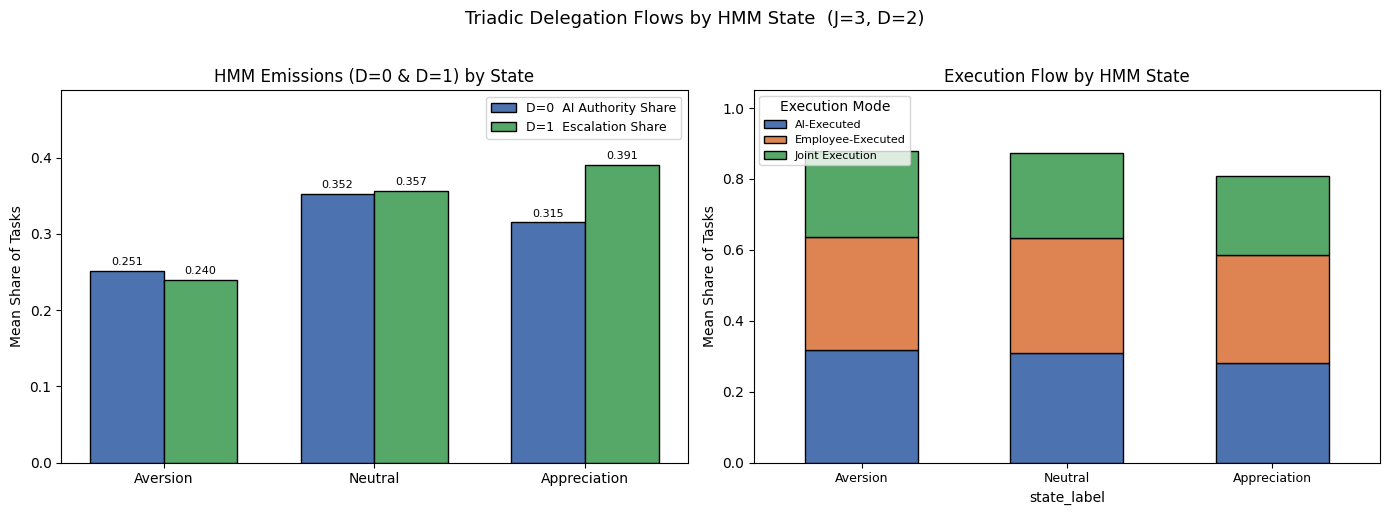

═══  Statistical Tests: Emissions by State  ═══

ai_decision_authority_share: ANOVA p = 0.000000
  Aversion vs Neutral: p = 0.000000
  Aversion vs Appreciation: p = 0.000000
  Neutral vs Appreciation: p = 0.000000

share_authority_esc: ANOVA p = 0.000000
  Aversion vs Neutral: p = 0.000000
  Aversion vs Appreciation: p = 0.000000
  Neutral vs Appreciation: p = 0.000000

═══  Chi-Squared: AI Authority Majority × HMM State  ═══

share_authority_ai  AI-Majority  Non-AI-Majority
state_label                                     
Aversion                      0              272
Neutral                       7             2079
Appreciation                  4              638

χ² = 2.21, p = 0.330980, dof = 2

═══  Employee Override During Execution by State  ═══



,Mean Override Rate,Std,Count
state_label,,,
Aversion,0.0349,0.0294,272
Neutral,0.0346,0.0296,2086
Appreciation,0.0336,0.0294,642


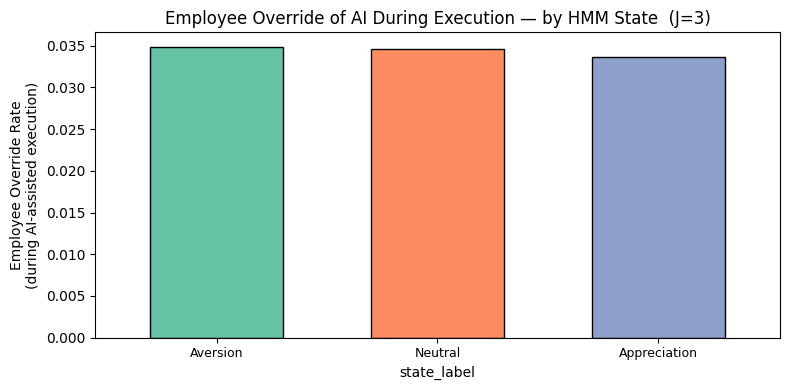


════════════════════════════════════════════════════════════
✓ Triadic delegation flows — J=3, D=2 HMM.
  D=0 : ai_decision_authority_share
  D=1 : share_authority_esc
  States : Aversion | Neutral | Appreciation
════════════════════════════════════════════════════════════


In [45]:
# ============================================================
# Triadic Delegation Flows — Task-Level Evidence (3-state, D=2)
# ============================================================

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from IPython.display import display

print(f"Loading from: {xlsx_path.resolve()}\n")
print("═══  Loading Task-Level Episode Tables  ═══\n")

dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
exec_ep = pd.read_excel(xlsx_path, sheet_name="execution_episode")
print(f"decision_episode : {dec_ep.shape[0]:,} tasks  ({dec_ep.shape[1]} cols)")
print(f"execution_episode: {exec_ep.shape[0]:,} tasks  ({exec_ep.shape[1]} cols)")

dec_ep["is_ai_accepted"] = ((dec_ep["manager_action"] == "accept") & (dec_ep["escalation_flag"] == 0)).astype(int)
dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)

emp_override_col = "employee_override_during_execution"

# 1) Primary merge on episode_id
exec_mode_ep = exec_ep[["episode_id", "execution_mode"]].copy()
exec_mode_ep[emp_override_col] = exec_ep[emp_override_col] if emp_override_col in exec_ep.columns else 0
exec_mode_agg_ep = (
    exec_mode_ep.groupby("episode_id")
    .agg(execution_mode=("execution_mode", lambda x: x.mode().iloc[0]),
         any_emp_override=(emp_override_col, "max"))
    .reset_index()
)

tasks = dec_ep.merge(exec_mode_agg_ep, on="episode_id", how="left")
match_rate = float(tasks["execution_mode"].notna().mean())
print(f"\nEpisode_id merge coverage: {match_rate:.2%}")

# 2) Fallback merge if episode_id keys do not overlap
if match_rate < 0.05:
    print("⚠️ Low merge coverage on episode_id. Trying fallback: site_id + within-site row order.")
    if ("site_id" in dec_ep.columns) and ("site_id" in exec_ep.columns):
        dec_fb = dec_ep.reset_index(drop=True).copy()
        exec_fb = exec_ep.reset_index(drop=True).copy()

        dec_fb["_seq_site"] = dec_fb.groupby("site_id").cumcount()
        exec_fb["_seq_site"] = exec_fb.groupby("site_id").cumcount()

        exec_mode_fb = exec_fb[["site_id", "_seq_site", "execution_mode"]].copy()
        exec_mode_fb["any_emp_override"] = (
            exec_fb[emp_override_col] if emp_override_col in exec_fb.columns else 0
        )

        tasks = dec_fb.merge(exec_mode_fb, on=["site_id", "_seq_site"], how="left")
        tasks = tasks.drop(columns=["_seq_site"], errors="ignore")

        match_rate = float(tasks["execution_mode"].notna().mean())
        print(f"Fallback merge coverage (site_id + within-site order): {match_rate:.2%}")
    else:
        print("⚠️ Fallback skipped: site_id not available in both sheets.")

tasks["any_emp_override"] = tasks.get("any_emp_override", 0).fillna(0)
print(f"Merged task table: {tasks.shape[0]:,} rows")

print("\n═══  Per Manager-Period D=2 Emission Shares  ═══\n")

task_agg = (
    tasks.groupby(["manager_id", "period_id"])
    .agg(
        n_tasks_total=("episode_id", "count"),
        n_ai_accepted=("is_ai_accepted", "sum"),
        n_escalated=("is_escalated", "sum"),
    )
    .reset_index()
)
task_agg["share_authority_ai"] = task_agg["n_ai_accepted"] / task_agg["n_tasks_total"]
task_agg["share_authority_esc"] = task_agg["n_escalated"] / task_agg["n_tasks_total"]

exec_counts = (
    tasks.groupby(["manager_id", "period_id", "execution_mode"])
    .size().unstack(fill_value=0).reset_index()
)
exec_counts.columns.name = None
for c in ["ai", "human", "joint"]:
    if c not in exec_counts.columns:
        exec_counts[c] = 0
exec_counts.rename(columns={"ai": "n_exec_ai", "human": "n_exec_employee", "joint": "n_exec_joint"}, inplace=True)

emp_override_agg = (
    tasks.groupby(["manager_id", "period_id"])
    .agg(emp_override_rate=("any_emp_override", "mean"))
    .reset_index()
)

task_agg = (
    task_agg
    .merge(exec_counts, on=["manager_id", "period_id"], how="left")
    .merge(emp_override_agg, on=["manager_id", "period_id"], how="left")
    .fillna(0)
)

exec_total = (task_agg["n_exec_ai"] + task_agg["n_exec_employee"] + task_agg["n_exec_joint"]).replace(0, np.nan)
task_agg["share_exec_ai"] = task_agg["n_exec_ai"] / exec_total
task_agg["share_exec_employee"] = task_agg["n_exec_employee"] / exec_total
task_agg["share_exec_joint"] = task_agg["n_exec_joint"] / exec_total
task_agg[["share_exec_ai", "share_exec_employee", "share_exec_joint"]] = task_agg[["share_exec_ai", "share_exec_employee", "share_exec_joint"]].fillna(0)

task_state = task_agg.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"],
    how="inner"
)
task_state["state_label"] = task_state["most_likely_state"].map(label_map)
print(f"Task-State merged: {task_state.shape[0]:,} manager-period observations")

state_labels_ordered = [label_map[s] for s in state_order_1idx]
state_order_0idx = [s - 1 for s in state_order_1idx]
print(f"State order: {state_labels_ordered}\n")

print("═══  Observed D=2 Emission Means by HMM State  ═══")
print("    (compare to µ[j,0] and µ[j,1] from the fitted HMM)\n")

em_by_state = (
    task_state.groupby("state_label")[["share_authority_ai", "share_authority_esc"]]
    .mean().reindex(state_labels_ordered)
)
em_by_state.columns = ["D=0  ai_decision_authority_share", "D=1  share_authority_esc"]
display(em_by_state.round(4))

print("\n  HMM model µ:")
if "y_sc" in globals() and y_sc is not None:
    try:
        mu_unsc = y_sc.inverse_transform(best_model.mu[state_order_0idx])
        mu_display = pd.DataFrame(mu_unsc, index=state_labels_ordered,
                                  columns=["D=0  µ (HMM, unscaled)", "D=1  µ (HMM, unscaled)"])
    except Exception:
        mu_display = pd.DataFrame(best_model.mu[state_order_0idx], index=state_labels_ordered,
                                  columns=["D=0  µ (HMM, scaled)", "D=1  µ (HMM, scaled)"])
else:
    mu_display = pd.DataFrame(best_model.mu[state_order_0idx], index=state_labels_ordered,
                              columns=["D=0  µ (HMM, scaled)", "D=1  µ (HMM, scaled)"])
display(mu_display.round(4))

print("\n═══  Execution Flow Distribution by HMM State  ═══\n")
exec_by_state = (
    task_state.groupby("state_label")[["share_exec_ai", "share_exec_employee", "share_exec_joint"]]
    .mean().reindex(state_labels_ordered)
)
exec_by_state.columns = ["AI-Executed", "Employee-Executed", "Joint Execution"]
display(exec_by_state.round(4))

colors_d2 = ["#4C72B0", "#55A868"]
colors_exc = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(state_labels_ordered))
width = 0.35

bars_d0 = axes[0].bar(x - width/2, em_by_state["D=0  ai_decision_authority_share"], width,
                      label="D=0  AI Authority Share", color=colors_d2[0], edgecolor="k")
bars_d1 = axes[0].bar(x + width/2, em_by_state["D=1  share_authority_esc"], width,
                      label="D=1  Escalation Share", color=colors_d2[1], edgecolor="k")
axes[0].set_xticks(x)
axes[0].set_xticklabels(state_labels_ordered, fontsize=10)
axes[0].set_ylabel("Mean Share of Tasks")
axes[0].set_title("HMM Emissions (D=0 & D=1) by State", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max(em_by_state.values.max() * 1.25, 0.4))
for bar in list(bars_d0) + list(bars_d1):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

exec_by_state.plot(kind="bar", stacked=True, ax=axes[1], color=colors_exc, edgecolor="k", width=0.55)
axes[1].set_title("Execution Flow by HMM State", fontsize=12)
axes[1].set_ylabel("Mean Share of Tasks")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[1].legend(title="Execution Mode", fontsize=8, loc="upper left")
axes[1].set_ylim(0, 1.05)

plt.suptitle(f"Triadic Delegation Flows by HMM State  (J={len(state_labels_ordered)}, D=2)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("═══  Statistical Tests: Emissions by State  ═══\n")
for col, label in [
    ("share_authority_ai", "ai_decision_authority_share"),
    ("share_authority_esc", "share_authority_esc"),
]:
    groups = [task_state.loc[task_state["state_label"] == st, col].dropna().values for st in state_labels_ordered]
    f_stat, p_all = f_oneway(*groups)
    print(f"{label}: ANOVA p = {p_all:.6f}")
    for st_a, st_b in itertools.combinations(state_labels_ordered, 2):
        g0 = task_state.loc[task_state["state_label"] == st_a, col].dropna().values
        g1 = task_state.loc[task_state["state_label"] == st_b, col].dropna().values
        _, p_pair = ttest_ind(g0, g1, equal_var=False)
        print(f"  {st_a} vs {st_b}: p = {p_pair:.6f}")
    print()

print("═══  Chi-Squared: AI Authority Majority × HMM State  ═══\n")
ct_auth = pd.crosstab(
    task_state["state_label"],
    (task_state["share_authority_ai"] > 0.5).map({True: "AI-Majority", False: "Non-AI-Majority"})
).reindex(state_labels_ordered)
print(ct_auth)
chi2_val, p_chi, dof, _ = chi2_contingency(ct_auth.fillna(0))
print(f"\nχ² = {chi2_val:.2f}, p = {p_chi:.6f}, dof = {dof}")

print("\n═══  Employee Override During Execution by State  ═══\n")
override_by_state = (
    task_state.groupby("state_label")["emp_override_rate"]
    .agg(["mean", "std", "count"]).reindex(state_labels_ordered)
)
override_by_state.columns = ["Mean Override Rate", "Std", "Count"]
display(override_by_state.round(4))

fig2, ax2 = plt.subplots(figsize=(8, 4))
override_by_state["Mean Override Rate"].plot(
    kind="bar", ax=ax2, color=sns.color_palette("Set2", len(state_labels_ordered)), edgecolor="k", width=0.6
)
ax2.set_ylabel("Employee Override Rate\n(during AI-assisted execution)")
ax2.set_title(f"Employee Override of AI During Execution — by HMM State  (J={len(state_labels_ordered)})")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print(f"✓ Triadic delegation flows — J={len(state_labels_ordered)}, D=2 HMM.")
print("  D=0 : ai_decision_authority_share")
print("  D=1 : share_authority_esc")
print("  States : " + " | ".join(state_labels_ordered))
print("═" * 60)

## State-Dependent Time Trend of Delegation Decisions

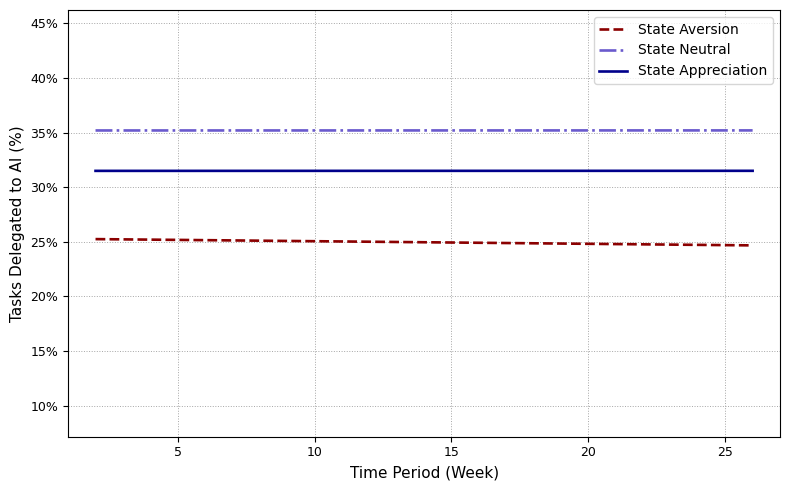

✔ Saved: state_time_trend_D0_ai_authority.png


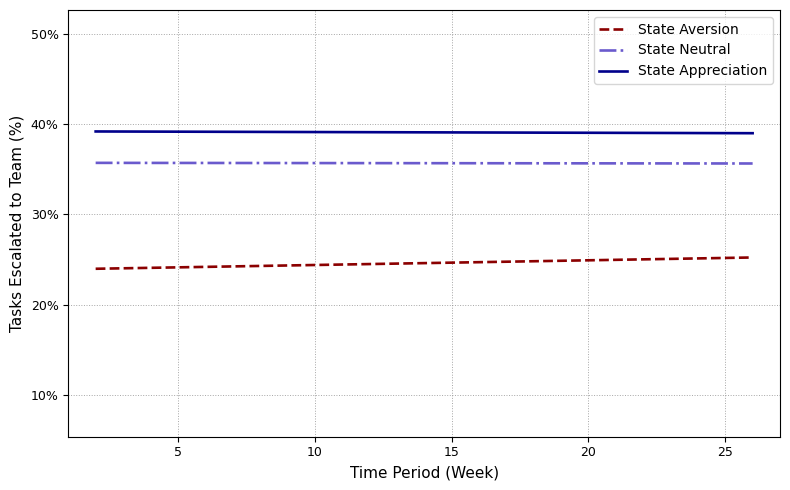

✔ Saved: state_time_trend_D1_escalation.png


In [46]:
# ============================================================
# State-Dependent Time Trend of Delegation Decisions (3-state ready)
# Two separate figures — one per emission (D=0 and D=1)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import linregress

emissions = [
    ("share_authority_ai",  "Tasks Delegated to AI (%)",  "state_time_trend_D0_ai_authority.png"),
    ("share_authority_esc", "Tasks Escalated to Team (%)", "state_time_trend_D1_escalation.png"),
]

assert "state_labels_ordered" in globals(), "state_labels_ordered missing. Run the triadic flow cell first."
assert "task_state" in globals(), "task_state missing. Run the triadic flow cell first."

base_colors = ["#8B0000", "#6A5ACD", "#00008B", "#2E8B57"]
base_styles = ["--", "-.", "-", ":"]

state_styles = {
    st: dict(color=base_colors[i % len(base_colors)], ls=base_styles[i % len(base_styles)], lw=1.9, label=f"State {st}")
    for i, st in enumerate(state_labels_ordered)
}

for col, ylabel, fname in emissions:
    trend_df = (
        task_state.groupby(["period_id", "state_label"])[col]
        .mean()
        .reset_index()
    )
    trend_df[col] *= 100
    trend_df = trend_df.sort_values("period_id")
    periods = np.sort(trend_df["period_id"].unique())

    fig, ax = plt.subplots(figsize=(8, 5))

    for state, sty in state_styles.items():
        sub = trend_df[trend_df["state_label"] == state].sort_values("period_id")
        if sub.shape[0] < 2:
            continue
        t = sub["period_id"].values.astype(float)
        y = sub[col].values
        slope, intercept, *_ = linregress(t, y)
        t_fit = np.array([periods.min(), periods.max()])
        y_fit = intercept + slope * t_fit
        ax.plot(t_fit, y_fit, color=sty["color"], ls=sty["ls"], lw=sty["lw"], label=sty["label"])

    ax.set_xlabel("Time Period (Week)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.set_xlim(periods.min() - 1, periods.max() + 1)
    ax.set_ylim(max(0, trend_df[col].min() - 10), min(100, trend_df[col].max() + 10))
    ax.grid(True, ls=":", lw=0.7, color="gray", alpha=0.7)
    ax.legend(fontsize=10, frameon=True)
    ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✔ Saved: {fname}")

State,Aversion,Neutral,Appreciation
N obs (manager-period),272,2086,642
N obs (%),9.07%,69.53%,21.40%
Avg tasks / period,51.5,51.5,51.4
AI authority share (μ),34.06%,53.78%,54.78%
AI authority share (σ),4.91%,1.51%,0.86%
Escalation share (μ),21.71%,36.23%,35.22%
Escalation share (σ),4.49%,1.61%,1.00%
Manager-retained (implied),44.23%,9.98%,10.00%
Exec: AI-only (%),31.80%,30.94%,28.04%
Exec: Employee-only (%),31.84%,32.28%,30.52%


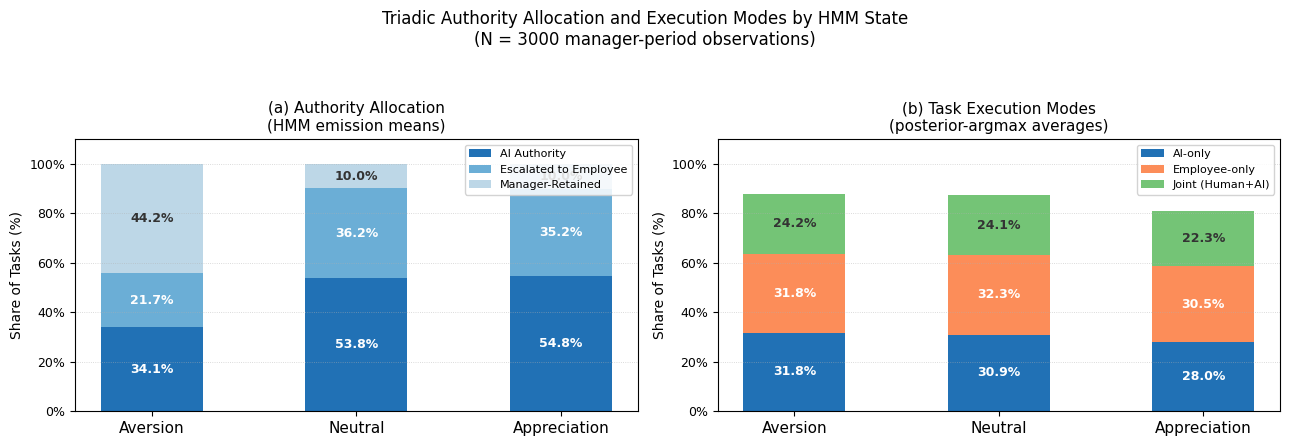

✔ Saved: triadic_authority_execution_by_state.png

══════════════════════════════════════════════════════
 TRIADIC AUTHORITY ALLOCATION & EXECUTION MODES — SUMMARY
══════════════════════════════════════════════════════

Total observations: 3000 manager-period units
  Aversion: N=272 (9.07%)
  Neutral: N=2086 (69.53%)
  Appreciation: N=642 (21.40%)


,Pair,Metric,p-value,sig
0,Aversion vs Neutral,AI authority share,0.0000,***
1,Aversion vs Neutral,Escalation share,0.0000,***
2,Aversion vs Neutral,Manager-retained (obs.),0.0000,***
3,Aversion vs Neutral,AI-only execution,0.4596,n.s.
4,Aversion vs Neutral,Employee-only exec.,0.6837,n.s.
5,Aversion vs Neutral,Joint execution,0.8211,n.s.
6,Aversion vs Neutral,Employee override,0.8939,n.s.
7,Aversion vs Appreciation,AI authority share,0.0000,***
8,Aversion vs Appreciation,Escalation share,0.0000,***
9,Aversion vs Appreciation,Manager-retained (obs.),0.0000,***


In [47]:
# ============================================================
# Triadic Authority Allocation and Execution Modes by HMM State (3-state ready)
# ============================================================

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.stats import ttest_ind

_labels = [label_map[s] for s in state_order_1idx]
_idx0 = [s - 1 for s in state_order_1idx]
_J = len(_labels)

mu_arr = mu_orig if "mu_orig" in globals() else (mu_orig_ if "mu_orig_" in globals() else best_model.mu)
sig_arr = sigma_orig if "sigma_orig" in globals() else (sigma_orig_ if "sigma_orig_" in globals() else np.exp(best_model.log_sigma))

ai_mu = [float(mu_arr[_idx0[i], 0]) for i in range(_J)]
esc_mu = [float(mu_arr[_idx0[i], 1]) for i in range(_J)]
mgr_mu = [1.0 - ai_mu[i] - esc_mu[i] for i in range(_J)]
ai_sd = [float(sig_arr[_idx0[i], 0]) for i in range(_J)]
esc_sd = [float(sig_arr[_idx0[i], 1]) for i in range(_J)]

grp = task_state.groupby("state_label")
exec_ai = {lbl: float(grp.get_group(lbl)["share_exec_ai"].mean()) for lbl in _labels}
exec_emp = {lbl: float(grp.get_group(lbl)["share_exec_employee"].mean()) for lbl in _labels}
exec_jnt = {lbl: float(grp.get_group(lbl)["share_exec_joint"].mean()) for lbl in _labels}
emp_ovr = {lbl: float(grp.get_group(lbl)["emp_override_rate"].mean()) for lbl in _labels}
n_tasks = {lbl: float(grp.get_group(lbl)["n_tasks_total"].mean()) for lbl in _labels}
n_obs = task_state["state_label"].value_counts().to_dict()


def _stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "** "
    if p < 0.10:
        return "*  "
    return "n.s."


task_state["mgr_retained_obs"] = 1 - task_state["share_authority_ai"] - task_state["share_authority_esc"]
_state_groups = {lbl: task_state[task_state["state_label"] == lbl] for lbl in _labels}

rows_html = []
for i, lbl in enumerate(_labels):
    rows_html.append({
        "State": lbl,
        "N obs (manager-period)": n_obs.get(lbl, 0),
        "N obs (%)": f"{100 * n_obs.get(lbl, 0) / sum(n_obs.values()):.2f}%",
        "Avg tasks / period": f"{n_tasks[lbl]:.1f}",
        "AI authority share (μ)": f"{ai_mu[i]:.2%}",
        "AI authority share (σ)": f"{ai_sd[i]:.2%}",
        "Escalation share (μ)": f"{esc_mu[i]:.2%}",
        "Escalation share (σ)": f"{esc_sd[i]:.2%}",
        "Manager-retained (implied)": f"{mgr_mu[i]:.2%}",
        "Exec: AI-only (%)": f"{exec_ai[lbl]:.2%}",
        "Exec: Employee-only (%)": f"{exec_emp[lbl]:.2%}",
        "Exec: Joint (%)": f"{exec_jnt[lbl]:.2%}",
        "Employee override rate": f"{emp_ovr[lbl]:.2%}",
    })

summary_df = pd.DataFrame(rows_html).set_index("State")
html_out = [
    "<h4>Table: Triadic Authority Allocation and Execution Modes by HMM State</h4>",
    "<p style='font-size:0.85em;color:#555;'>"
    "Authority allocation shows HMM emission means (μ) and standard deviations (σ) "
    "on the original scale. Manager-retained share is implied as 1 − AI − Escalation. "
    "Execution mode shares are posterior-argmax averages.</p>",
    summary_df.T.to_html(border=1, classes="table table-sm"),
]
display(HTML("\n".join(html_out)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(_J)
width = 0.5
cols_a = ["#2171b5", "#6baed6", "#bdd7e7"]
cols_e = ["#2171b5", "#fc8d59", "#74c476"]

ax = axes[0]
ai_vals = [ai_mu[i] for i in range(_J)]
esc_vals = [esc_mu[i] for i in range(_J)]
mgr_vals = [mgr_mu[i] for i in range(_J)]
ax.bar(x, [v * 100 for v in ai_vals], width, label="AI Authority", color=cols_a[0])
ax.bar(x, [v * 100 for v in esc_vals], width, bottom=[v * 100 for v in ai_vals], label="Escalated to Employee", color=cols_a[1])
ax.bar(x, [v * 100 for v in mgr_vals], width, bottom=[(ai_vals[i] + esc_vals[i]) * 100 for i in range(_J)], label="Manager-Retained", color=cols_a[2])
for i in range(_J):
    ax.text(i, ai_vals[i] / 2 * 100, f"{ai_vals[i]:.1%}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.text(i, (ai_vals[i] + esc_vals[i] / 2) * 100, f"{esc_vals[i]:.1%}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.text(i, (ai_vals[i] + esc_vals[i] + mgr_vals[i] / 2) * 100, f"{mgr_vals[i]:.1%}", ha="center", va="center", fontsize=9, color="#333", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(_labels, fontsize=11)
ax.set_ylabel("Share of Tasks (%)")
ax.set_ylim(0, 110)
ax.set_title("(a) Authority Allocation\n(HMM emission means)", fontsize=11)
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax.set_yticks(range(0, 110, 20))
ax.set_yticklabels([f"{v}%" for v in range(0, 110, 20)], fontsize=9)
ax.grid(True, axis="y", ls=":", lw=0.6, alpha=0.6)

ax = axes[1]
exec_ai_vals = [exec_ai[lbl] for lbl in _labels]
exec_emp_vals = [exec_emp[lbl] for lbl in _labels]
exec_jnt_vals = [exec_jnt[lbl] for lbl in _labels]
ax.bar(x, [v * 100 for v in exec_ai_vals], width, label="AI-only", color=cols_e[0])
ax.bar(x, [v * 100 for v in exec_emp_vals], width, bottom=[v * 100 for v in exec_ai_vals], label="Employee-only", color=cols_e[1])
ax.bar(x, [v * 100 for v in exec_jnt_vals], width, bottom=[(exec_ai_vals[i] + exec_emp_vals[i]) * 100 for i in range(_J)], label="Joint (Human+AI)", color=cols_e[2])
for i in range(_J):
    for val, bot, c in [
        (exec_ai_vals[i], 0, "white"),
        (exec_emp_vals[i], exec_ai_vals[i], "white"),
        (exec_jnt_vals[i], exec_ai_vals[i] + exec_emp_vals[i], "#333"),
    ]:
        ax.text(i, (bot + val / 2) * 100, f"{val:.1%}", ha="center", va="center", fontsize=9, color=c, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(_labels, fontsize=11)
ax.set_ylabel("Share of Tasks (%)")
ax.set_ylim(0, 110)
ax.set_title("(b) Task Execution Modes\n(posterior-argmax averages)", fontsize=11)
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax.set_yticks(range(0, 110, 20))
ax.set_yticklabels([f"{v}%" for v in range(0, 110, 20)], fontsize=9)
ax.grid(True, axis="y", ls=":", lw=0.6, alpha=0.6)

fig.suptitle("Triadic Authority Allocation and Execution Modes by HMM State\n"
             f"(N = {sum(n_obs.values())} manager-period observations)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("triadic_authority_execution_by_state.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: triadic_authority_execution_by_state.png")

print("\n══════════════════════════════════════════════════════")
print(" TRIADIC AUTHORITY ALLOCATION & EXECUTION MODES — SUMMARY")
print("══════════════════════════════════════════════════════")
print(f"\nTotal observations: {sum(n_obs.values())} manager-period units")
for lbl in _labels:
    pct = 100 * n_obs.get(lbl, 0) / sum(n_obs.values())
    print(f"  {lbl}: N={n_obs.get(lbl, 0)} ({pct:.2f}%)")

pair_rows = []
for a, b in itertools.combinations(_labels, 2):
    for metric, col in [
        ("AI authority share", "share_authority_ai"),
        ("Escalation share", "share_authority_esc"),
        ("Manager-retained (obs.)", "mgr_retained_obs"),
        ("AI-only execution", "share_exec_ai"),
        ("Employee-only exec.", "share_exec_employee"),
        ("Joint execution", "share_exec_joint"),
        ("Employee override", "emp_override_rate"),
    ]:
        g1 = _state_groups[a][col].dropna().values
        g2 = _state_groups[b][col].dropna().values
        _, p = ttest_ind(g1, g2, equal_var=False)
        pair_rows.append({"Pair": f"{a} vs {b}", "Metric": metric, "p-value": p, "sig": _stars(p)})

pairwise_df = pd.DataFrame(pair_rows)
display(pairwise_df.round(4))

In [48]:
# ── Helper: integer hundredths-of-percent arithmetic ─────────────────────────
def _h(x): return int(round(x * 10000))
def _pct(h): return "{}.{:02d}%".format(h // 100, h % 100)

assert "_state_groups" in globals(), "_state_groups missing. Run prior triadic authority cell first."
assert "_labels" in globals(), "_labels missing. Run prior triadic authority cell first."

print("\n─── Authority Allocation (state means, exact 2-decimal percentages) ───")
rows_auth = []
for lbl in _labels:
    grp = _state_groups[lbl]
    ai_h = _h(grp["share_authority_ai"].mean())
    esc_h = _h(grp["share_authority_esc"].mean())
    mgr_h = 10000 - ai_h - esc_h
    assert ai_h + esc_h + mgr_h == 10000
    rows_auth.append({
        "State": lbl,
        "AI authority share": _pct(ai_h),
        "Escalation share": _pct(esc_h),
        "Manager-retained (obs.)": _pct(mgr_h),
    })
auth_df = pd.DataFrame(rows_auth).set_index("State")
display(auth_df)

print("\n─── Execution Modes (state means, exact 2-decimal percentages) ───")
rows_exec = []
for lbl in _labels:
    grp = _state_groups[lbl]
    eai_h = _h(grp["share_exec_ai"].mean())
    eemp_h = _h(grp["share_exec_employee"].mean())
    ejnt_h = 10000 - eai_h - eemp_h
    assert eai_h + eemp_h + ejnt_h == 10000
    rows_exec.append({
        "State": lbl,
        "AI-only execution": _pct(eai_h),
        "Employee-only exec.": _pct(eemp_h),
        "Joint execution": _pct(ejnt_h),
        "Employee override": f"{grp['emp_override_rate'].mean():.2%}",
    })
exec_df = pd.DataFrame(rows_exec).set_index("State")
display(exec_df)

print("\n✔ All partition columns verified for each state: sum = 100.00%")


─── Authority Allocation (state means, exact 2-decimal percentages) ───


,AI authority share,Escalation share,Manager-retained (obs.)
State,,,
Aversion,25.13%,24.00%,50.87%
Neutral,35.19%,35.67%,29.14%
Appreciation,31.50%,39.06%,29.44%



─── Execution Modes (state means, exact 2-decimal percentages) ───


,AI-only execution,Employee-only exec.,Joint execution,Employee override
State,,,,
Aversion,31.80%,31.84%,36.36%,3.49%
Neutral,30.94%,32.28%,36.78%,3.46%
Appreciation,28.04%,30.52%,41.44%,3.36%



✔ All partition columns verified for each state: sum = 100.00%


In [49]:
# Quick diagnostic: execution_mode raw categories and mapped counts
import pandas as pd

if "exec_ep" not in globals():
    exec_ep = pd.read_excel(xlsx_path, sheet_name="execution_episode")

print("Raw execution_mode value counts:")
print(exec_ep["execution_mode"].value_counts(dropna=False).head(20))

# Recreate the exact mapping logic used in the triadic flow cell
exec_mode = exec_ep[["episode_id", "execution_mode"]].copy()
exec_mode_agg = (
    exec_mode.groupby("episode_id")
    .agg(execution_mode=("execution_mode", lambda x: x.mode().iloc[0]))
    .reset_index()
)
exec_counts = (
    exec_mode_agg.groupby("execution_mode")
    .size()
    .rename("n_episodes")
    .sort_values(ascending=False)
)
print("\nEpisode-level modal execution_mode counts:")
print(exec_counts)

print("\nCategories expected by current code: ['ai', 'human', 'joint']")
print("Observed categories:", sorted(exec_counts.index.astype(str).unique().tolist())[:20])

Raw execution_mode value counts:
execution_mode
human    51223
ai       48809
joint    38145
Name: count, dtype: int64

Episode-level modal execution_mode counts:
execution_mode
human    51223
ai       48809
joint    38145
Name: n_episodes, dtype: int64

Categories expected by current code: ['ai', 'human', 'joint']
Observed categories: ['ai', 'human', 'joint']


In [50]:
# Diagnostic: merge coverage between decision_episode and execution_episode
import pandas as pd

dec_ep_chk = pd.read_excel(xlsx_path, sheet_name="decision_episode")
exec_ep_chk = pd.read_excel(xlsx_path, sheet_name="execution_episode")

exec_mode_chk = exec_ep_chk[["episode_id", "execution_mode"]].copy()
exec_mode_agg_chk = (
    exec_mode_chk.groupby("episode_id")
    .agg(execution_mode=("execution_mode", lambda x: x.mode().iloc[0]))
    .reset_index()
)

tasks_chk = dec_ep_chk.merge(exec_mode_agg_chk, on="episode_id", how="left")

matched = tasks_chk["execution_mode"].notna().sum()
total = len(tasks_chk)
print(f"Matched execution_mode rows: {matched}/{total} ({matched/total:.2%})")
print("\nexecution_mode distribution after merge (including NaN):")
print(tasks_chk["execution_mode"].value_counts(dropna=False).head(10))

# Recreate manager-period aggregation quickly
exec_counts_chk = (
    tasks_chk.groupby(["manager_id", "period_id", "execution_mode"])
    .size().unstack(fill_value=0).reset_index()
)
exec_counts_chk.columns.name = None
for c in ["ai", "human", "joint"]:
    if c not in exec_counts_chk.columns:
        exec_counts_chk[c] = 0

print("\nNon-zero totals in aggregated columns:")
print({c: int(exec_counts_chk[c].sum()) for c in ["ai", "human", "joint"]})

Matched execution_mode rows: 0/160661 (0.00%)

execution_mode distribution after merge (including NaN):
execution_mode
NaN    160661
Name: count, dtype: int64

Non-zero totals in aggregated columns:
{'ai': 0, 'human': 0, 'joint': 0}


In [51]:
# Diagnostic: find correct join keys between decision_episode and execution_episode
import pandas as pd

dec_cols = set(dec_ep_chk.columns if "dec_ep_chk" in globals() else pd.read_excel(xlsx_path, sheet_name="decision_episode", nrows=1).columns)
exe_cols = set(exec_ep_chk.columns if "exec_ep_chk" in globals() else pd.read_excel(xlsx_path, sheet_name="execution_episode", nrows=1).columns)
common_cols = sorted(dec_cols & exe_cols)
print("Common columns:", common_cols)

if "dec_ep_chk" not in globals():
    dec_ep_chk = pd.read_excel(xlsx_path, sheet_name="decision_episode")
if "exec_ep_chk" not in globals():
    exec_ep_chk = pd.read_excel(xlsx_path, sheet_name="execution_episode")

candidates = [
    ["episode_id"],
    ["manager_id", "period_id"],
    ["manager_id", "period_id", "task_id"],
    ["manager_id", "period_id", "decision_id"],
]

for keys in candidates:
    if all(k in dec_ep_chk.columns for k in keys) and all(k in exec_ep_chk.columns for k in keys):
        left = dec_ep_chk[keys].drop_duplicates()
        right = exec_ep_chk[keys].drop_duplicates()
        m = left.merge(right, on=keys, how="inner").shape[0]
        print(f"Keys {keys}: unique-left={left.shape[0]}, unique-right={right.shape[0]}, intersections={m}")

Common columns: ['episode_id', 'site_id']
Keys ['episode_id']: unique-left=160661, unique-right=138177, intersections=0


In [52]:
# Diagnostic: normalized episode_id overlap
import re

def _norm_id(series):
    s = series.astype(str).str.strip().str.lower()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"[^a-z0-9]", "", regex=True)
    return s

left_ids = _norm_id(dec_ep_chk["episode_id"]).dropna()
right_ids = _norm_id(exec_ep_chk["episode_id"]).dropna()

left_set = set(left_ids.unique())
right_set = set(right_ids.unique())
inter = left_set & right_set

print(f"Normalized unique IDs (decision): {len(left_set)}")
print(f"Normalized unique IDs (execution): {len(right_set)}")
print(f"Normalized intersections: {len(inter)}")

if len(inter) > 0:
    print("Sample intersections:", list(sorted(inter))[:10])
else:
    print("No overlap even after normalization.")

Normalized unique IDs (decision): 160661
Normalized unique IDs (execution): 138177
Normalized intersections: 0
No overlap even after normalization.


In [55]:
# Quick diagnostic: verify delegation time-trend computations
import numpy as np
import pandas as pd
from scipy.stats import linregress

assert "task_state" in globals(), "task_state missing"
assert "state_labels_ordered" in globals(), "state_labels_ordered missing"

emissions = [
    ("share_authority_ai", "Tasks Delegated to AI (%)"),
    ("share_authority_esc", "Tasks Escalated to Team (%)"),
]

all_rows = []
for col, label in emissions:
    trend_df = (
        task_state.groupby(["period_id", "state_label"])[col]
        .mean()
        .reset_index()
        .sort_values("period_id")
    )
    trend_df[col] = trend_df[col] * 100.0

    for state in state_labels_ordered:
        sub = trend_df[trend_df["state_label"] == state].sort_values("period_id")
        if sub.shape[0] < 2:
            all_rows.append({
                "Metric": label,
                "State": state,
                "N periods": int(sub.shape[0]),
                "Slope (%-points/week)": np.nan,
                "p-value": np.nan,
                "R^2": np.nan,
                "Mean level (%)": float(sub[col].mean()) if sub.shape[0] else np.nan,
            })
            continue

        t = sub["period_id"].astype(float).to_numpy()
        y = sub[col].to_numpy()
        lr = linregress(t, y)
        all_rows.append({
            "Metric": label,
            "State": state,
            "N periods": int(sub.shape[0]),
            "Slope (%-points/week)": float(lr.slope),
            "p-value": float(lr.pvalue),
            "R^2": float(lr.rvalue**2),
            "Mean level (%)": float(y.mean()),
        })

diag_df = pd.DataFrame(all_rows)
print("Delegation decision time-trend diagnostics")
print(diag_df.round({"Slope (%-points/week)": 4, "p-value": 6, "R^2": 4, "Mean level (%)": 3}).to_string(index=False))

# data coverage check for plotting assumptions
coverage = (
    task_state.groupby(["state_label", "period_id"]).size()
    .rename("n_obs")
    .reset_index()
)
print("\nCoverage summary by state (manager-period counts per week):")
print(
    coverage.groupby("state_label")["n_obs"]
    .agg(["count", "min", "median", "max"])
    .rename(columns={"count": "N weeks"})
    .to_string()
)


Delegation decision time-trend diagnostics
                     Metric        State  N periods  Slope (%-points/week)  p-value    R^2  Mean level (%)
  Tasks Delegated to AI (%)     Aversion         25                -0.0239 0.805298 0.0027          24.962
  Tasks Delegated to AI (%)      Neutral         25                 0.0002 0.989420 0.0000          35.189
  Tasks Delegated to AI (%) Appreciation         25                 0.0002 0.997286 0.0000          31.493
Tasks Escalated to Team (%)     Aversion         25                 0.0521 0.668881 0.0081          24.611
Tasks Escalated to Team (%)      Neutral         25                -0.0029 0.830970 0.0020          35.670
Tasks Escalated to Team (%) Appreciation         25                -0.0080 0.849887 0.0016          39.083

Coverage summary by state (manager-period counts per week):
              N weeks  min  median  max
state_label                            
Appreciation       25   12    27.0   35
Aversion           25    3 